TODO


*   get list of all extra attacker goals
*   get list of all goalie pulls (3)

my stepdad doesn't believe that pulling the goalie is a good idea because he's "never actually seen it work"



## Goalie Pull Brainstorm

[PWHL Data reference](https://github.com/IsabelleLefebvre97/PWHL-Data-Reference)

Are extra attacker goals labelled? no. But we can annotate them because the "plus" array will have length 6.

Look for goalie change events:

```
"event": "goalie_change",
"goalie_in_id": null,
"goalie_out_id": "48",
```


#Part 1: Successful extra attacker goals

### Import Game Data

In [ ]:
pip install requests

In [ ]:
import requests

def get_game_data(game_id):
  play_by_play_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=gc&tab=pxpverbose&game_id="+str(game_id)+"&key=446521baf8c38984&client_code=pwhl")
  # print(response.status_code)
  game_summary_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=gc&tab=gamesummary&game_id="+str(game_id)+"&key=446521baf8c38984&client_code=pwhl")
  # print(response.status_code)

  if game_summary_response.status_code != 200:
    return None

  pbp_data = play_by_play_response.json()
  game_summary_data = game_summary_response.json()

  play_by_play = pbp_data["GC"]["Pxpverbose"]
  game_summary = game_summary_data["GC"]["Gamesummary"]

  play_by_play_truncated = play_by_play[2:] # remove initial goalie change events ("goalie in")

  # only include goals, penalties, events in regulation.
  play_by_play_goals_penalties_goalie_changes = [play for play in play_by_play_truncated if play["event"] == "goal" or play["event"] == "penalty" or play["event"] == "goalie_change"]
  play_by_play_regulation = [play for play in play_by_play_goals_penalties_goalie_changes if play["period_id"] == "1" or play["period_id"] == "2" or play["period_id"] == "3"]
  return play_by_play_goals_penalties_goalie_changes, game_summary


In [ ]:
import pandas as pd

In [ ]:
pbp, game_summary = get_game_data(3)

In [ ]:
game_summary.keys()

dict_keys(['meta', 'txt_title', 'txt_scoring', 'txt_total', 'txt_shots', 'game_ident', 'game_date', 'game_length', 'status_title', 'status_value', 'periods', 'shootout', 'visitor', 'home', 'visitor_division', 'visitor_division_id', 'home_division', 'home_division_id', 'mvp_type', 'shootoutDetail', 'mvps', 'venue', 'referee1', 'referee2', 'linesman1', 'linesman2', 'officialsOnIce', 'officialsOffIce', 'homeShootout', 'visitorShootout', 'benchGoalCount', 'penalties', 'goals', 'goalies', 'home_team_lineup', 'visitor_team_lineup', 'game_date_iso_8601', 'coaches', 'pimBench', 'powerPlayGoals', 'powerPlayCount', 'goalCount', 'assistCount', 'pointsCount', 'pimTotal', 'infCount', 'shotsByPeriod', 'penaltyshots', 'totalFaceoffs', 'totalHits', 'totalGoals', 'totalShots', 'totalShotsOn', 'goalsByPeriod'])

In [ ]:
def filter_goals(play_by_play):
    goals = [play for play in play_by_play if play["event"] == "goal"]
    return goals

def filter_goalie_change(play_by_play):
    goals = [play for play in play_by_play if play["event"] == "goalie_change"]
    return goals

def convert_play_by_play_to_dataframe(play_by_play, game_summary):
    # Load the JSON file into a DataFrame
    play_by_play_df = pd.json_normalize(play_by_play)

    # Convert the DataFrame to a CSV file
    play_by_play_df.to_csv('pwhl_pbp.csv', index=False)

    return play_by_play_df

def get_goals_df_for_game_id(game_id):
    game_data = get_game_data(game_id)
    if game_data is None:
      return None

    pbp, game_summary = get_game_data(game_id)
    goals_pbp = filter_goals(pbp)
    goalie_changes = filter_goalie_change(pbp)
    goals_df = pd.json_normalize(goals_pbp)
    goalie_changes_df = pd.json_normalize(goalie_changes)

    return goals_df, goalie_changes_df, game_summary

def convert_goalie_change_time_to_total_minutes(period_id, time_str):
    # Convert period_id to integer
    period_num = int(period_id)

    # Each period is 20 minutes. Adjust for 0-indexed period calculation.
    # For period 1, minutes from 0 to 20
    # For period 2, minutes from 20 to 40
    # For period 3, minutes from 40 to 60
    minutes_passed_in_previous_periods = (period_num - 1) * 20

    # Parse M:SS format time string
    minutes_in_period, seconds_in_period = map(int, time_str.split(':'))

    # Calculate total minutes in game
    total_minutes_in_game = minutes_passed_in_previous_periods + minutes_in_period + seconds_in_period / 60.0
    return total_minutes_in_game

team_name_map = {
    1: "Boston Fleet",
    2: "Minnesota Frost",
    3: "Montréal Victoire",
    4: "New York Sirens",
    5: "Ottawa Charge",
    6: "Toronto Sceptres",
    8: "Seattle Torrent",
    9: "Vancouver Goldeneyes",
}

In [ ]:
def format_goals_df(goals_df, game_id, game_summary):
  goals_df_formatted = goals_df.copy()
  goals_df_formatted = goals_df_formatted[["id", "team_id", "goal_player_id", "time", "time_formatted", "period", "game_winning", "game_tieing", "plus", "minus", "empty_net", "goal_scorer.first_name", "goal_scorer.last_name"]]
  # goals_df_formatted['game_id'] = int(game_id)
  goals_df_formatted.insert(loc=0, column='game_id', value=int(game_id))
  goals_df_formatted["id"] = goals_df_formatted["id"].astype(int)
  goals_df_formatted["team_id"] = goals_df_formatted["team_id"].astype(int)
  goals_df_formatted["goal_player_id"] = goals_df_formatted["goal_player_id"].astype(int)
  goals_df_formatted["goal_team_name"] = goals_df_formatted["team_id"].map(team_name_map)
  goals_df_formatted["plus"] = goals_df_formatted["plus"].tolist()
  goals_df_formatted["minus"] = goals_df_formatted["minus"].tolist()
  goals_df_formatted["plus_strength"] = goals_df_formatted["plus"].map(len)
  goals_df_formatted["minus_strength"] = goals_df_formatted["minus"].map(len)
  goals_df_formatted["extra_attacker"] = goals_df_formatted["plus_strength"].map(lambda x: x == 6)

  home_team_id = int(game_summary["home"]["id"]) #ie 1
  away_team_id = int(game_summary["visitor"]["id"])

  goals_df_formatted["game_date"] = game_summary["game_date"]
  goals_df_formatted["home_team_name"] = team_name_map[home_team_id]
  goals_df_formatted["away_team_name"] = team_name_map[away_team_id]
  goals_df_formatted["goal_against_team_name"] = goals_df_formatted["team_id"].map(lambda team_id: team_name_map[home_team_id] if team_id == away_team_id else team_name_map[away_team_id])

  return goals_df_formatted


def format_goalie_changes_df(goalie_changes_df, game_id, game_summary):
  # Define the expected columns
  expected_columns = ["team_id", "period_id", "time", "goalie_in_id", "goalie_out_id", "goalie_in_info.last_name", "goalie_out_info.last_name"]

  # If the DataFrame is empty or doesn't have the expected columns, create an empty one with the columns
  if goalie_changes_df.empty or not all(col in goalie_changes_df.columns for col in expected_columns):
    goalie_changes_df_formatted = pd.DataFrame(columns=expected_columns)
  else:
    goalie_changes_df_formatted = goalie_changes_df.copy()
    goalie_changes_df_formatted = goalie_changes_df_formatted[expected_columns]

  home_team_id = int(game_summary["home"]["id"]) #ie 1
  away_team_id = int(game_summary["visitor"]["id"])

  goalie_changes_df_formatted["game_date"] = game_summary["game_date"]
  goalie_changes_df_formatted["home_team_name"] = team_name_map[home_team_id]
  goalie_changes_df_formatted["team_name"] = goalie_changes_df_formatted["team_id"].map(team_name_map)
  goalie_changes_df_formatted["away_team_name"] = team_name_map[away_team_id]
  goalie_changes_df_formatted.insert(loc=0, column='game_id', value=int(game_id))

  return goalie_changes_df_formatted

In [ ]:
def get_goals_between_ids_inclusive_exclusive(start_game_id, end_game_id):
  goals_dfs = []
  goalie_change_dfs = []
  for game_id in range(start_game_id, end_game_id):
    game_info = get_goals_df_for_game_id(game_id)

    if game_info is not None:
      temp_df_goals, temp_df_goalie_changes, game_summary = game_info
      goals_dfs.append(format_goals_df(temp_df_goals, game_id, game_summary))
      goalie_change_dfs.append(format_goalie_changes_df(temp_df_goalie_changes, game_id, game_summary))

  all_goals = pd.concat(goals_dfs, ignore_index=True)
  all_goalie_changes = pd.concat(goalie_change_dfs, ignore_index=True)
  return all_goals, all_goalie_changes

In [ ]:
S3_FIRST_GAME_ID = 210
S3_LAST_GAME_ID = 329

S3_PLAYOFFS_FIRST_GAME_ID = 338
S3_PLAYOFFS_LAST_GAME_ID = 351
# NOTE - GAME 346 IS MISSING

In [ ]:
# s3_goals, s3_goalie_changes = get_goals_between_ids_inclusive_exclusive(S3_FIRST_GAME_ID, S3_FIRST_GAME_ID + 2)

In [ ]:
# s3_goalie_changes.head()

In [ ]:
s3_goals, s3_goalie_changes = get_goals_between_ids_inclusive_exclusive(S3_FIRST_GAME_ID, S3_LAST_GAME_ID + 1)

In [ ]:
list(s3_goals.columns)

['game_id',
 'id',
 'team_id',
 'goal_player_id',
 'time',
 'time_formatted',
 'period',
 'game_winning',
 'game_tieing',
 'plus',
 'minus',
 'empty_net',
 'goal_scorer.first_name',
 'goal_scorer.last_name',
 'goal_team_name',
 'plus_strength',
 'minus_strength',
 'extra_attacker',
 'game_date',
 'home_team_name',
 'away_team_name',
 'goal_against_team_name']

In [ ]:
s3_goals.head()

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_scorer.first_name,goal_scorer.last_name,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name
0,210,1058,2,20,4:00,4:00,1st,0,0,"[{'player_id': '162', 'jersey_number': '9', 't...",...,Kendall,Coyne Schofield,Minnesota Frost,5,5,False,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,Toronto Sceptres
1,210,1059,6,44,17:05,17:05,1st,0,0,"[{'player_id': '63', 'jersey_number': '9', 'te...",...,Ella,Shelton,Toronto Sceptres,5,5,False,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,Minnesota Frost
2,210,1060,6,317,5:44,5:44,3rd,1,0,"[{'player_id': '68', 'jersey_number': '6', 'te...",...,Kiara,Zanon,Toronto Sceptres,5,5,False,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,Minnesota Frost
3,211,1061,8,210,14:40,14:40,1st,0,0,"[{'player_id': '196', 'jersey_number': '3', 't...",...,Julia,Gosling,Seattle Torrent,5,5,False,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,Vancouver Goldeneyes
4,211,1062,9,75,17:41,17:41,1st,0,0,"[{'player_id': '180', 'jersey_number': '11', '...",...,Sarah,Nurse,Vancouver Goldeneyes,5,5,False,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,Seattle Torrent


In [ ]:
# s3_playoffs_goals = get_goals_between_ids_inclusive_exclusive(S3_PLAYOFFS_FIRST_GAME_ID, S3_PLAYOFFS_LAST_GAME_ID + 1)

In [ ]:
# s3_playoffs_goals.head()

In [ ]:
# s3_all_goals = pd.concat([s3_goals, s3_playoffs_goals], ignore_index=True)
s3_all_goals = s3_goals

In [ ]:
# Extract unique game metadata from s3_goals
games_metadata = s3_all_goals[['game_id', 'game_date', 'home_team_name', 'away_team_name']].drop_duplicates().copy()

# Assuming all games in s3_all_goals are regular season games for now
regular_season_games_metadata = games_metadata.copy()
playoffs_games_metadata = pd.DataFrame(columns=games_metadata.columns) # Empty DataFrame for playoffs if no playoff data

# Define team acronym map
team_acronym_map = {
    "Boston Fleet": "BOS",
    "Minnesota Frost": "MIN",
    "Montréal Victoire": "MTL",
    "New York Sirens": "NY",
    "Ottawa Charge": "OTT",
    "Toronto Sceptres": "TOR",
    "Seattle Torrent": "SEA",
    "Vancouver Goldeneyes": "VAN",
}

In [ ]:

s3_extra_attacker_goals_all = s3_all_goals[s3_all_goals['extra_attacker'] == True].copy()


In [ ]:
def convert_to_total_minutes(period, time_str):
    period_map = {'1st': 0, '2nd': 1, '3rd': 2}
    period_num = period_map.get(period, -1)

    if period_num == -1:
        return np.nan

    minutes_in_period, seconds_in_period = map(int, time_str.split(':'))

    # Each period is 20 minutes for regulation
    total_minutes_in_game = (period_num * 20) + minutes_in_period + seconds_in_period / 60.0
    return total_minutes_in_game

s3_extra_attacker_goals_all['total_minutes_in_game'] = s3_extra_attacker_goals_all.apply(
    lambda row: convert_to_total_minutes(row['period'], row['time']), axis=1
)

In [ ]:
s3_extra_attacker_goals_all

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_scorer.last_name,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name,total_minutes_in_game
8,211,1066,9,169,17:57,17:57,3rd,0,0,"[{'player_id': '198', 'jersey_number': '12', '...",...,Thompson,Vancouver Goldeneyes,6,5,True,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,Seattle Torrent,57.950000
47,221,1108,4,40,3:15,3:15,1st,0,0,"[{'player_id': '207', 'jersey_number': '16', '...",...,Levis,New York Sirens,6,6,True,"Wednesday, December 3, 2025",Seattle Torrent,New York Sirens,Seattle Torrent,3.250000
72,228,1134,1,243,5:27,5:27,2nd,1,0,"[{'player_id': '52', 'jersey_number': '3', 'te...",...,Huber,Boston Fleet,6,5,True,"Wednesday, December 17, 2025",New York Sirens,Boston Fleet,New York Sirens,25.450000
107,234,1169,8,36,19:34,19:34,3rd,0,0,"[{'player_id': '62', 'jersey_number': '2', 'te...",...,Eldridge,Seattle Torrent,6,5,True,"Sunday, December 21, 2025",Seattle Torrent,Boston Fleet,Boston Fleet,59.566667
149,243,1213,3,274,19:35,19:35,3rd,0,0,"[{'player_id': '32', 'jersey_number': '7', 'te...",...,Mlýnková,Montréal Victoire,6,5,True,"Friday, January 2, 2026",New York Sirens,Montréal Victoire,New York Sirens,59.583333
171,247,1238,3,42,19:31,19:31,3rd,0,0,"[{'player_id': '32', 'jersey_number': '7', 'te...",...,Roque,Montréal Victoire,6,5,True,"Sunday, January 4, 2026",Montréal Victoire,Minnesota Frost,Minnesota Frost,59.516667
179,249,1249,9,252,18:58,18:58,3rd,0,0,"[{'player_id': '161', 'jersey_number': '13', '...",...,Karvinen,Vancouver Goldeneyes,6,5,True,"Friday, January 9, 2026",Ottawa Charge,Vancouver Goldeneyes,Ottawa Charge,58.966667
200,255,1268,6,73,18:18,18:18,3rd,0,0,"[{'player_id': '63', 'jersey_number': '9', 'te...",...,Maltais,Toronto Sceptres,6,5,True,"Wednesday, January 14, 2026",Boston Fleet,Toronto Sceptres,Boston Fleet,58.300000
232,262,1300,2,23,18:58,18:58,3rd,0,0,"[{'player_id': '24', 'jersey_number': '2', 'te...",...,Pannek,Minnesota Frost,6,5,True,"Wednesday, January 21, 2026",Minnesota Frost,Montréal Victoire,Montréal Victoire,58.966667
303,276,1375,6,65,18:56,18:56,3rd,0,0,"[{'player_id': '63', 'jersey_number': '9', 'te...",...,Compher,Toronto Sceptres,6,5,True,"Tuesday, March 3, 2026",Toronto Sceptres,Montréal Victoire,Montréal Victoire,58.933333


In [ ]:
len(s3_extra_attacker_goals_all)

23

In [ ]:
len(s3_all_goals)

550

In [ ]:
team_name_map

{1: 'Boston Fleet',
 2: 'Minnesota Frost',
 3: 'Montréal Victoire',
 4: 'New York Sirens',
 5: 'Ottawa Charge',
 6: 'Toronto Sceptres',
 8: 'Seattle Torrent',
 9: 'Vancouver Goldeneyes'}

In [ ]:
team_id_map = {name: team_id for team_id, name in team_name_map.items()}

In [ ]:
team_id_map["Seattle Torrent"]

8

# FIX GOALIE PULL DATA

In [ ]:
import pandas as pd
import numpy as np

# Initialize the 'added_manually' column in s3_goalie_changes if it doesn't exist
# This column will be False for all currently loaded rows.
if 'added_manually' not in s3_goalie_changes.columns:
    s3_goalie_changes['added_manually'] = False

def add_goalie_change_row(
    current_df,
    game_id,
    team_id,
    period_id,
    time_in_period_str,
    goalie_in_id=np.nan, # Use numpy.nan for None for numerical columns
    goalie_out_id=np.nan,
    goalie_in_last_name=None,
    goalie_out_last_name=None,
    games_metadata_df=None, # Expecting the global games_metadata
    team_name_mapping=None # Expecting the global team_name_map
):
    """
    Adds a new goalie change event row to the s3_goalie_changes DataFrame.

    Args:
        current_df (pd.DataFrame): The DataFrame to which the new row will be added (e.g., s3_goalie_changes).
        game_id (int): The ID of the game.
        team_id (int): The ID of the team making the goalie change.
        period_id (int): The period number (1, 2, or 3).
        time_in_period_str (str): The time within the period in 'M:SS' format.
        goalie_in_id (int, optional): The ID of the goalie entering the game. Defaults to None.
        goalie_out_id (int, optional): The ID of the goalie leaving the game. Defaults to None.
        goalie_in_last_name (str, optional): Last name of the goalie entering. Defaults to None.
        goalie_out_last_name (str, optional): Last name of the goalie leaving. Defaults to None.
        games_metadata_df (pd.DataFrame, optional): DataFrame containing game metadata.
                                                   Used to infer game_date, home_team_name, away_team_name.
        team_name_mapping (dict, optional): Dictionary mapping team_id to team_name.

    Returns:
        pd.DataFrame: The updated DataFrame with the new goalie change event.
    """

    # Infer game_date, home_team_name, away_team_name from games_metadata_df
    game_info = games_metadata_df[games_metadata_df['game_id'] == game_id]
    game_date_str = game_info['game_date'].iloc[0] if not game_info.empty else None
    home_team_name = game_info['home_team_name'].iloc[0] if not game_info.empty else None
    away_team_name = game_info['away_team_name'].iloc[0] if not game_info.empty else None

    # Convert period_id to string for convert_goalie_change_time_to_total_minutes if needed
    period_id_str = str(period_id)

    # Calculate total_minutes_in_game
    total_minutes = convert_goalie_change_time_to_total_minutes(period_id_str, time_in_period_str)

    # Get team_name from mapping
    team_name_for_change = team_name_mapping.get(team_id) if team_name_mapping else None

    new_row = {
        'game_id': game_id,
        'team_id': team_id,
        'period_id': period_id_str, # Ensure period_id is string to match existing data
        'time': time_in_period_str,
        'goalie_in_id': goalie_in_id,
        'goalie_out_id': goalie_out_id,
        'goalie_in_info.last_name': goalie_in_last_name,
        'goalie_out_info.last_name': goalie_out_last_name,
        'game_date': game_date_str,
        'home_team_name': home_team_name,
        'team_name': team_name_for_change, # Name of the team making the change
        'away_team_name': away_team_name,
        'total_minutes_in_game': total_minutes,
        'added_manually': True
    }

    new_row_df = pd.DataFrame([new_row], columns=current_df.columns) # Ensure columns match

    updated_df = pd.concat([current_df, new_row_df], ignore_index=True)
    return updated_df

# Example usage:
# Let's add a hypothetical goalie pull for game_id 210 for Boston Fleet (id 1) in period 3 at 19:00
# Goalie out: 123 (Rooney), Goalie in: None (pull)

# Before adding:
# print("Original s3_goalie_changes length:", len(s3_goalie_changes))

# Game 234 - BOS vs SEA
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=234,
    team_id=team_id_map["Seattle Torrent"],
    period_id=3,
    time_in_period_str="17:05",
    goalie_out_id=155, # Example goalie out ID
    goalie_out_last_name="Schroeder", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 320 - SEA vs VAN
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=320,
    team_id=team_id_map["Vancouver Goldeneyes"], # VAN
    period_id=3,
    time_in_period_str="14:54",
    goalie_out_id=64, # Example goalie out ID
    goalie_out_last_name="Campbell", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 350 - SEA vs OTT
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=229,
    team_id=team_id_map["Ottawa Charge"],
    period_id=3,
    time_in_period_str="16:10",
    goalie_out_id=238, # Example goalie out ID
    goalie_out_last_name="Ahola", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 244 - MIN vs OTT
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=244,
    team_id=team_id_map["Minnesota Frost"],
    period_id=3,
    time_in_period_str="16:55",
    goalie_out_id=123, # Example goalie out ID
    goalie_out_last_name="Rooney", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 272 - TOR vs SEA
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=272,
    team_id=team_id_map["Seattle Torrent"], # SEATTLE
    period_id=3,
    time_in_period_str="17:48",
    goalie_out_id=250, # Example goalie out ID
    goalie_out_last_name="Murphy", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# CHECK GAMES WITHOUT AN EXTRA ATTACKER OR ENG
# Game 216 - SEA vs MIN
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=216,
    team_id=team_id_map["Seattle Torrent"], # SEATTLE
    period_id=3,
    time_in_period_str="16:32",
    goalie_out_id=155, # Example goalie out ID
    goalie_out_last_name="Schroeder", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 236 - SEA vs MTL
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=236,
    team_id=team_id_map["Montréal Victoire"],
    period_id=3,
    time_in_period_str="17:26", # Pulled with 2:34 left
    goalie_out_id=28, # Example goalie out ID
    goalie_out_last_name="Desbiens", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 246 - VAN vs BOS
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=246,
    team_id=team_id_map["Boston Fleet"],
    period_id=3,
    time_in_period_str="18:49",
    goalie_out_id=6, # Example goalie out ID
    goalie_out_last_name="Frankel", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 261 - TOR vs SEA
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=261,
    team_id=team_id_map["Toronto Sceptres"],
    period_id=3,
    time_in_period_str="18:27",
    goalie_out_id=211, # Example goalie out ID
    goalie_out_last_name="Kirk", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 278 - BOS vs NY
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=278,
    team_id=team_id_map["New York Sirens"],
    period_id=3,
    time_in_period_str="17:97",
    goalie_out_id=228, # Example goalie out ID
    goalie_out_last_name="Osborne", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 283 - BOS vs SEA
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=283,
    team_id=team_id_map["Boston Fleet"],
    period_id=3,
    time_in_period_str="18:49",
    goalie_out_id=41, # Example goalie out ID
    goalie_out_last_name="Levy", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 302 - BOS vs MIN
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=302,
    team_id=team_id_map["Minnesota Frost"],
    period_id=3,
    time_in_period_str="18:40",
    goalie_out_id=22, # Example goalie out ID
    goalie_out_last_name="Hensley", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 303 - SEA vs OTT
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=303,
    team_id=team_id_map["Seattle Torrent"],
    period_id=3,
    time_in_period_str="18:23",
    goalie_out_id=155, # Example goalie out ID
    goalie_out_last_name="Schroeder", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Game 303 - TOR vs MIN
s3_goalie_changes = add_goalie_change_row(
    current_df=s3_goalie_changes,
    game_id=321,
    team_id=team_id_map["Minnesota Frost"],
    period_id=3,
    time_in_period_str="18:19",
    goalie_out_id=123, # Example goalie out ID
    goalie_out_last_name="Rooney", # Example goalie out last name
    games_metadata_df=games_metadata,
    team_name_mapping=team_name_map
)

# Display the last few rows to see the added entry, or filter by game_id and added_manually
print("\nUpdated s3_goalie_changes (last 5 rows):")
display(s3_goalie_changes.tail())

print("\nManually added row(s):")
display(s3_goalie_changes[s3_goalie_changes['added_manually'] == True])


Updated s3_goalie_changes (last 5 rows):


,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually
275,278,4,3,17:97,NaN,228,None,Osborne,"Thursday, March 5, 2026",New York Sirens,New York Sirens,Boston Fleet,True
276,283,1,3,18:49,NaN,41,None,Levy,"Wednesday, March 11, 2026",Seattle Torrent,Boston Fleet,Boston Fleet,True
277,302,2,3,18:40,NaN,22,None,Hensley,"Sunday, March 29, 2026",Minnesota Frost,Minnesota Frost,Boston Fleet,True
278,303,8,3,18:23,NaN,155,None,Schroeder,"Sunday, March 29, 2026",Seattle Torrent,Seattle Torrent,Ottawa Charge,True
279,321,2,3,18:19,NaN,123,None,Rooney,"Sunday, April 19, 2026",Minnesota Frost,Minnesota Frost,Toronto Sceptres,True



Manually added row(s):


,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually
266,234,8,3,17:05,NaN,155,None,Schroeder,"Sunday, December 21, 2025",Seattle Torrent,Seattle Torrent,Boston Fleet,True
267,320,9,3,14:54,NaN,64,None,Campbell,"Saturday, April 18, 2026",Seattle Torrent,Vancouver Goldeneyes,Vancouver Goldeneyes,True
268,229,5,3,16:10,NaN,238,None,Ahola,"Wednesday, December 17, 2025",Seattle Torrent,Ottawa Charge,Ottawa Charge,True
269,244,2,3,16:55,NaN,123,None,Rooney,"Saturday, January 3, 2026",Ottawa Charge,Minnesota Frost,Minnesota Frost,True
270,272,8,3,17:48,NaN,250,None,Murphy,"Friday, February 27, 2026",Seattle Torrent,Seattle Torrent,Toronto Sceptres,True
271,216,8,3,16:32,NaN,155,None,Schroeder,"Friday, November 28, 2025",Seattle Torrent,Seattle Torrent,Minnesota Frost,True
272,236,3,3,17:26,NaN,28,None,Desbiens,"Tuesday, December 23, 2025",Seattle Torrent,Montréal Victoire,Montréal Victoire,True
273,246,1,3,18:49,NaN,6,None,Frankel,"Saturday, January 3, 2026",Boston Fleet,Boston Fleet,Vancouver Goldeneyes,True
274,261,6,3,18:27,NaN,211,None,Kirk,"Tuesday, January 20, 2026",Seattle Torrent,Toronto Sceptres,Toronto Sceptres,True
275,278,4,3,17:97,NaN,228,None,Osborne,"Thursday, March 5, 2026",New York Sirens,New York Sirens,Boston Fleet,True


In [ ]:
len(s3_goalie_changes)

280

# Visualize all extra attacker goals

In [ ]:
team_color_map = {
      "Seattle Torrent": "teal",
      "Toronto Sceptres": "RoyalBlue",
      "Boston Fleet": "green",
      "Montréal Victoire": "maroon",
      "Hamilton": "gold",
      "Detroit": "black",
      "Las Vegas": "Olive",
      "San Jose": "DeepSkyBlue",
      "Minnesota Frost": "MediumSlateBlue",
      "Ottawa Charge": "Crimson",
      "Vancouver Goldeneyes": "MediumBlue",
      "New York Sirens": "LightSeaGreen",
    };

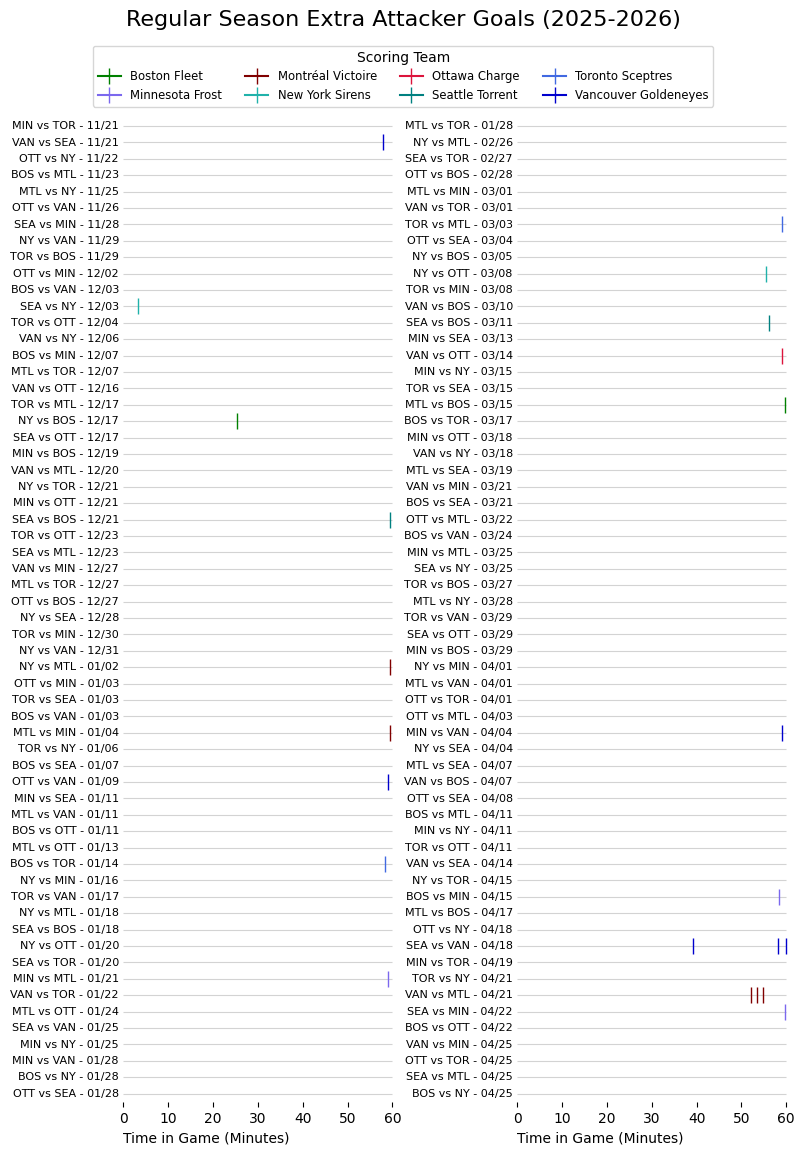

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

marker = '|'
markersize = 12
linewidth = 3

# Helper function to plot on a given ax with compact vertical spacing
def _plot_extra_attacker_goals_single_axis_compact(ax, games_metadata_df_subset, chart_title, extra_attacker_goals_df, team_color_map, team_acronym_map, markersize=20, label_fontsize=8, vertical_spacing_factor=0.75,  marker='|'):
    # Sort games_metadata_df_subset by date in descending order (latest games at bottom)
    games_metadata_df_subset = games_metadata_df_subset.sort_values(by='game_date_dt', ascending=False).reset_index(drop=True)

    # Remove the plot border for this specific ax
    for spine in ax.spines.values():
        spine.set_visible(False)

    num_games = len(games_metadata_df_subset)
    # y_pos for each game line, scaled by the vertical_spacing_factor
    y_pos = np.arange(num_games) * vertical_spacing_factor

    # Plot for each game
    for i, game_row in games_metadata_df_subset.iterrows():
        game_id = game_row['game_id']
        home_team = game_row['home_team_name']
        away_team = game_row['away_team_name']
        game_date_formatted = game_row['game_date_dt'].strftime('%m/%d') # Format date to MM/DD

        # Use acronyms for labels
        home_team_acronym = team_acronym_map.get(home_team, home_team)
        away_team_acronym = team_acronym_map.get(away_team, away_team)
        label_text = f"{home_team_acronym} vs {away_team_acronym} - {game_date_formatted}"
        # Position label to the left of the 0-minute mark, right-aligned to be close to the line
        ax.text(-1, y_pos[i], label_text, va='center', ha='right', fontsize=label_fontsize) # Adjusted x-coordinate to be -1, right-aligned

        # Horizontal line representing 60 minutes of regulation play (0 to 60 minutes)
        ax.hlines(y_pos[i], 0, 60, color='lightgray', linestyle='solid', linewidth=0.8)

        # Filter extra attacker goals for the current game
        game_extra_attacker_goals = extra_attacker_goals_df[extra_attacker_goals_df['game_id'] == game_id]

        # Plot dots for each extra attacker goal if any exist for this game
        for _, goal_row in game_extra_attacker_goals.iterrows():
            total_minutes = goal_row['total_minutes_in_game']
            scoring_team = goal_row['goal_team_name']
            color = team_color_map.get(scoring_team, 'gray')
            ax.plot(total_minutes, y_pos[i], marker, color=color, markersize=markersize, zorder=5)

    ax.set_xlabel('Time in Game (Minutes)', fontsize=10)
    ax.set_yticks([]) # Hide y-ticks as labels are custom
    # Adjusted x-limits to encompass labels more tightly and give more visual space to the 0-60 range
    ax.set_xlim(-25, 62)
    ax.set_xticks(np.arange(0, 61, 10)) # Set x-ticks to be non-negative, covering 0-60
    ax.set_ylim(-0.5 * vertical_spacing_factor, (num_games - 0.5) * vertical_spacing_factor) # Adjust y-limits to fit all game lines

# Main plotting function for the new request with compact spacing
def plot_extra_attacker_goals_halves_and_playoffs_compact(regular_season_metadata, playoffs_metadata, extra_attacker_goals_df, team_color_map, team_acronym_map, vertical_spacing_factor=0.75, marker='|'):
    # Ensure game_date is datetime for sorting
    regular_season_metadata_copy = regular_season_metadata.copy()
    regular_season_metadata_copy['game_date_dt'] = pd.to_datetime(regular_season_metadata_copy['game_date'])
    sorted_regular_season = regular_season_metadata_copy.sort_values(by='game_date_dt', ascending=True).reset_index(drop=True)

    # Split regular season into two halves
    midpoint = len(sorted_regular_season) // 2
    first_half_season = sorted_regular_season.iloc[:midpoint]
    second_half_season = sorted_regular_season.iloc[midpoint:]

    # --- Plot Regular Season Halves in 2 columns ---
    # Increased width to make the 0-60 lines appear longer, while keeping height for readability
    # Scale figure height based on the vertical_spacing_factor to maintain aspect ratio with reduced spacing
    fig_rs, axes_rs = plt.subplots(1, 2, figsize=(8, 12), sharey=False) # Changed height to 12 as requested
    fig_rs.suptitle('Regular Season Extra Attacker Goals (2025-2026)', fontsize=16, y=0.99) # Overall title, adjusted y-position to be higher

    # Plot first half
    _plot_extra_attacker_goals_single_axis_compact(axes_rs[0], first_half_season, 'First Half', extra_attacker_goals_df, team_color_map, team_acronym_map, markersize=markersize, label_fontsize=8, vertical_spacing_factor=vertical_spacing_factor, marker=marker)
    # Plot second half
    _plot_extra_attacker_goals_single_axis_compact(axes_rs[1], second_half_season, 'Second Half', extra_attacker_goals_df, team_color_map, team_acronym_map, markersize=markersize, label_fontsize=8, vertical_spacing_factor=vertical_spacing_factor, marker=marker)

    # Create a single legend for both regular season plots
    legend_elements = []
    unique_scoring_teams_rs = extra_attacker_goals_df[extra_attacker_goals_df['game_id'].isin(regular_season_metadata['game_id'])]['goal_team_name'].unique()
    for team in sorted(unique_scoring_teams_rs):
        color = team_color_map.get(team, 'gray')
        # For line markers, 'color' sets the marker color directly. 'markerfacecolor'/'markeredgecolor' are less applicable.
        legend_elements.append(plt.Line2D([0], [0], marker=marker, color=color, label=team, markersize=12,))

    if legend_elements:
        # Move legend to the top, below the suptitle, with slightly adjusted y and reduced borderaxespad
        fig_rs.legend(handles=legend_elements, title="Scoring Team", bbox_to_anchor=(0.5, 0.96), loc='upper center', ncol=4, borderaxespad=0., fontsize='small') # Adjusted bbox_to_anchor y to 0.96 and added fontsize='small'

    # Replaced tight_layout with subplots_adjust for finer control over spacing, adjusted top for legend/title space
    fig_rs.subplots_adjust(left=0.01, right=0.99, bottom=0.08, top=0.90, wspace=0.01) # Adjusted top to 0.90
    plt.show()

# Define regular_season_games_metadata and playoffs_games_metadata
# Extract unique game metadata from s3_goals
games_metadata = s3_all_goals[['game_id', 'game_date', 'home_team_name', 'away_team_name']].drop_duplicates().copy()

# Assuming all games in s3_all_goals are regular season games for now
regular_season_games_metadata = games_metadata.copy()
playoffs_games_metadata = pd.DataFrame(columns=games_metadata.columns) # Empty DataFrame for playoffs if no playoff data

# Define team acronym map
team_acronym_map = {
    "Boston Fleet": "BOS",
    "Minnesota Frost": "MIN",
    "Montréal Victoire": "MTL",
    "New York Sirens": "NY",
    "Ottawa Charge": "OTT",
    "Toronto Sceptres": "TOR",
    "Seattle Torrent": "SEA",
    "Vancouver Goldeneyes": "VAN",
}

# Call the new plotting function with existing dataframes and reduced vertical spacing
plot_extra_attacker_goals_halves_and_playoffs_compact(
    regular_season_games_metadata,
    playoffs_games_metadata,
    s3_extra_attacker_goals_all,
    team_color_map,
    team_acronym_map,
    vertical_spacing_factor=0.75, # Adjust this value to control spacing
    marker=marker,
)

In [ ]:
display(games_metadata.head())

,game_id,game_date,home_team_name,away_team_name
0,210,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres
3,211,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent
10,212,"Saturday, November 22, 2025",Ottawa Charge,New York Sirens
14,213,"Sunday, November 23, 2025",Boston Fleet,Montréal Victoire
16,214,"Tuesday, November 25, 2025",Montréal Victoire,New York Sirens


## Verify extra attacker goals

In [ ]:
goal_ids_to_remove = [
    1108, # there must have been a delayed penalty or something idk
    1134, # I still have no idea why this is listed lol
    1577, # Jenn Gardiner goal in the second period, I think they were in the middle of a line change
    1404, # game 283 - this is not a legit extra attacker goal
    1394, # game 279 - not a legit extra attacker goal
]

In [ ]:
s3_extra_attacker_goals = s3_extra_attacker_goals_all[~s3_extra_attacker_goals_all['id'].isin(goal_ids_to_remove)]

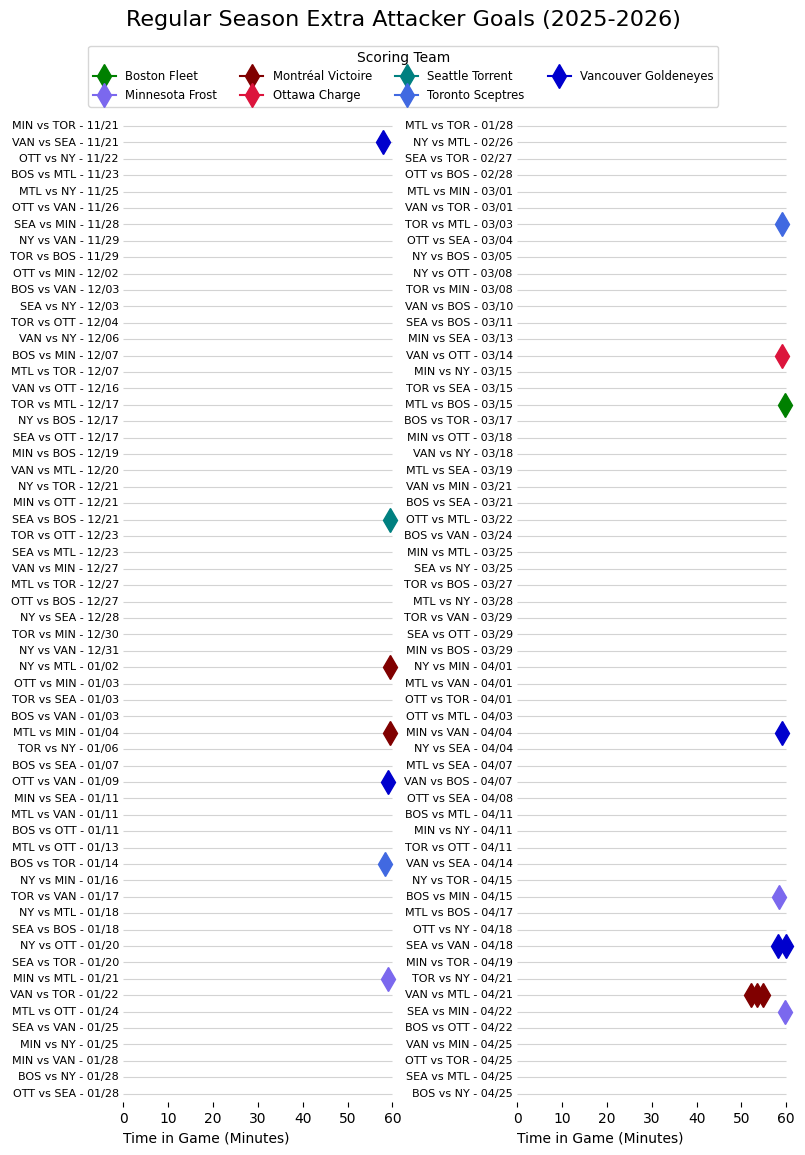

In [ ]:
plot_extra_attacker_goals_halves_and_playoffs_compact(
    regular_season_games_metadata,
    playoffs_games_metadata,
    s3_extra_attacker_goals,
    team_color_map,
    team_acronym_map,
    vertical_spacing_factor=0.75, # Adjust this value to control spacing
    marker='d',
)

In [ ]:
len(s3_extra_attacker_goals)

18

# Question: what percent of goals were an empty net goal?

In [ ]:
print(f"Length of s3_extra_attacker_goals: {len(s3_extra_attacker_goals)}")
print(f"Length of s3_all_goals: {len(s3_all_goals)}")

Length of s3_extra_attacker_goals: 18
Length of s3_all_goals: 550


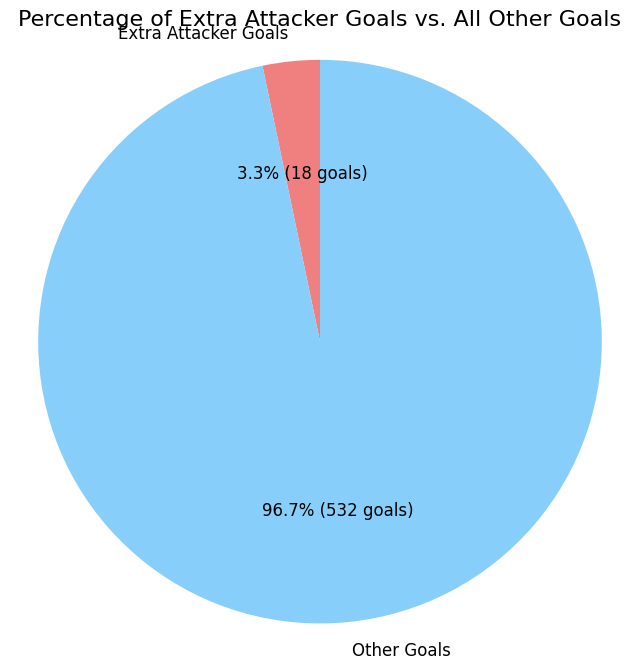

In [ ]:
import matplotlib.pyplot as plt

# Get the counts for extra attacker goals and all goals
num_extra_attacker_goals = len(s3_extra_attacker_goals)
num_all_goals = len(s3_all_goals)

# Calculate non-extra attacker goals
num_non_extra_attacker_goals = num_all_goals - num_extra_attacker_goals

# Data for the pie chart
labels = ['Extra Attacker Goals', 'Other Goals']
sizes = [num_extra_attacker_goals, num_non_extra_attacker_goals]
colors = ['lightcoral', 'lightskyblue'] # Custom colors

fig2, ax2 = plt.subplots(figsize=(8, 8))
ax2.pie(sizes, labels=labels, colors=colors, autopct=lambda p: '{:.1f}% ({} goals)'.format(p, int(p/100.*sum(sizes))),
        shadow=False, startangle=90, textprops={'fontsize': 12})
ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Percentage of Extra Attacker Goals vs. All Other Goals', fontsize=16)
plt.show()

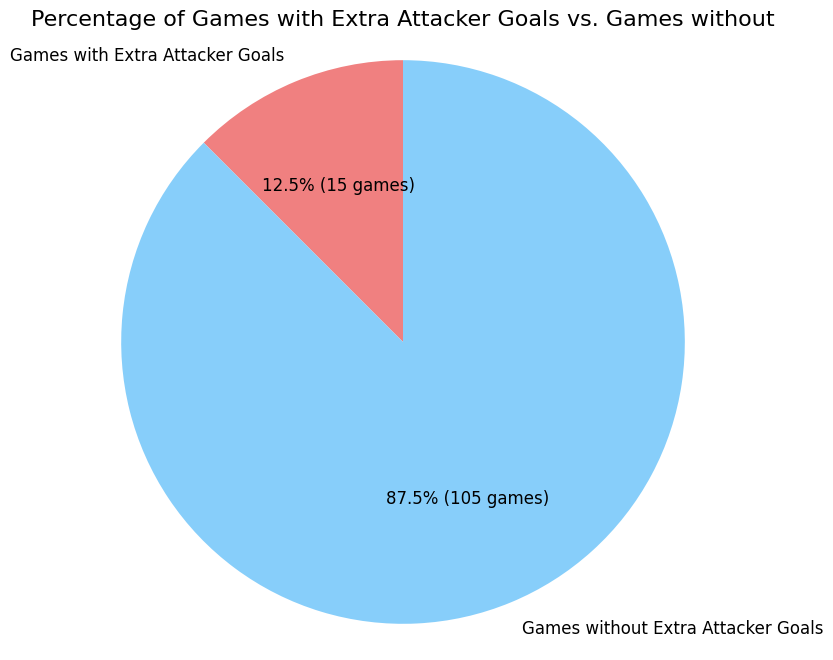

In [ ]:
import matplotlib.pyplot as plt

# Get the number of unique games with extra attacker goals
num_games_with_ea_goals = s3_extra_attacker_goals['game_id'].nunique()

# Get the total number of unique games
num_total_games = s3_all_goals['game_id'].nunique()

# Calculate the number of games without extra attacker goals
num_games_without_ea_goals = num_total_games - num_games_with_ea_goals

# Data for the pie chart
labels = ['Games with Extra Attacker Goals', 'Games without Extra Attacker Goals']
sizes = [num_games_with_ea_goals, num_games_without_ea_goals]
colors = ['lightcoral', 'lightskyblue'] # Custom colors

fig3, ax3 = plt.subplots(figsize=(8, 8))
ax3.pie(sizes, labels=labels, colors=colors, autopct=lambda p: '{:.1f}% ({} games)'.format(p, int(p/100.*sum(sizes))),
        shadow=False, startangle=90, textprops={'fontsize': 12})
ax3.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Percentage of Games with Extra Attacker Goals vs. Games without', fontsize=16)
plt.show()

# Question: Who had the most extra attacker goals?

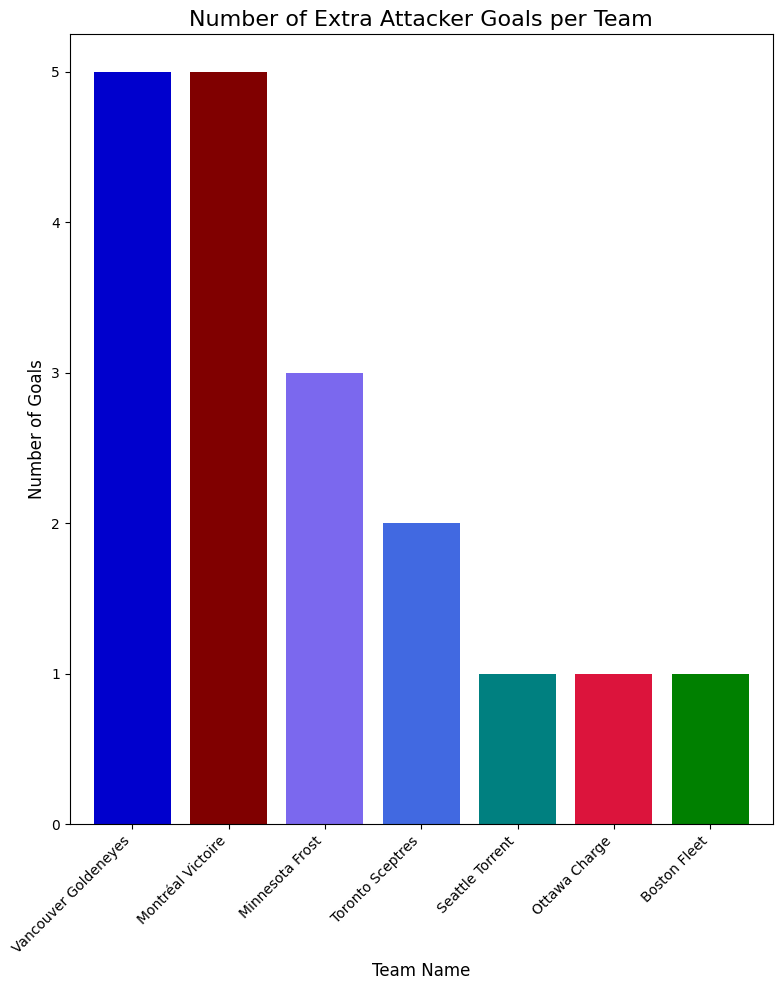

In [ ]:
import matplotlib.pyplot as plt

goal_counts = s3_extra_attacker_goals['goal_team_name'].value_counts()

# Get colors for the teams present in goal_counts
colors = [team_color_map.get(team, 'gray') for team in goal_counts.index] # Use 'gray' for any missing teams

plt.figure(figsize=(8, 10)) # Adjusted for a 4:5 aspect ratio
goal_counts.plot.bar(color=colors, width=0.8) # Increased bar width
plt.title('Number of Extra Attacker Goals per Team', fontsize=16) # Increased title font size
plt.xlabel('Team Name', fontsize=12) # Increased x-label font size
plt.ylabel('Number of Goals', fontsize=12) # Increased y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Increased x-tick font size
plt.yticks(fontsize=10) # Increased y-tick font size
plt.tight_layout()
plt.show()

In [ ]:
all_teams_df = pd.DataFrame({'goal_team_name': s3_all_goals['goal_team_name'].unique()})

extra_attacker_summary = s3_extra_attacker_goals.groupby('goal_team_name').agg(
    extra_attacker_goals_count=('id', 'count'),
    goal_ids=('id', lambda x: list(x)) # Aggregate goal_ids into a list
).reset_index()

# Merge with all_teams_df to include teams with zero extra attacker goals
extra_attacker_goal_summary = pd.merge(
    all_teams_df,
    extra_attacker_summary,
    on='goal_team_name',
    how='left'
)

# Fill NaN values for teams that had no extra attacker goals
extra_attacker_goal_summary['extra_attacker_goals_count'] = extra_attacker_goal_summary['extra_attacker_goals_count'].fillna(0).astype(int)
extra_attacker_goal_summary['goal_ids'] = extra_attacker_goal_summary['goal_ids'].apply(lambda x: x if isinstance(x, list) else [])

display(extra_attacker_goal_summary.sort_values(by='extra_attacker_goals_count', ascending=False).reset_index(drop=True))

,goal_team_name,extra_attacker_goals_count,goal_ids
0,Vancouver Goldeneyes,5,"[1066, 1249, 1518, 1583, 1584]"
1,Montréal Victoire,5,"[1213, 1238, 1593, 1594, 1595]"
2,Minnesota Frost,3,"[1300, 1563, 1607]"
3,Toronto Sceptres,2,"[1268, 1375]"
4,Seattle Torrent,1,[1169]
5,Boston Fleet,1,[1422]
6,Ottawa Charge,1,[1413]
7,New York Sirens,0,[]


# Question: Who had the most extra attacker goals against?

,Team Name,Extra Attacker Goals Against Count
0,Seattle Torrent,4
1,Vancouver Goldeneyes,4
2,Boston Fleet,3
3,Montréal Victoire,3
4,Minnesota Frost,2
5,New York Sirens,1
6,Ottawa Charge,1


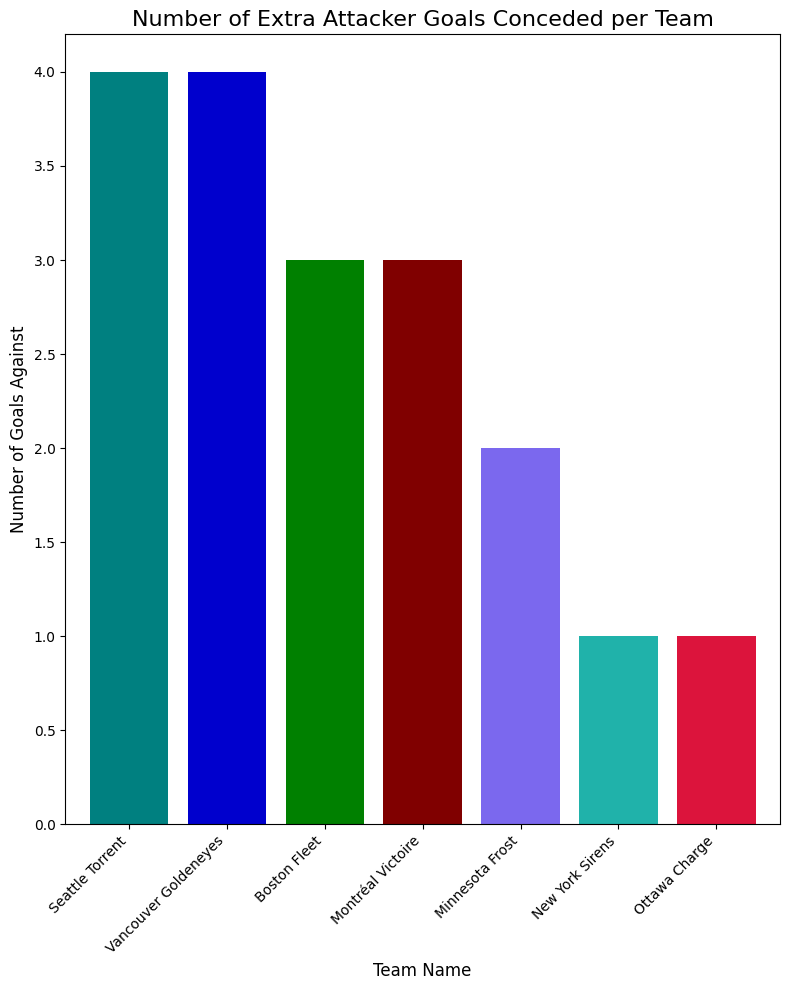

In [ ]:
goals_against_counts = s3_extra_attacker_goals['goal_against_team_name'].value_counts()

# Create a DataFrame for the table
goals_against_table = goals_against_counts.reset_index()
goals_against_table.columns = ['Team Name', 'Extra Attacker Goals Against Count']
display(goals_against_table)

# Get colors for the teams present in goals_against_counts
colors_against = [team_color_map.get(team, 'gray') for team in goals_against_counts.index]

plt.figure(figsize=(8, 10)) # Adjusted for a 4:5 aspect ratio
goals_against_counts.plot.bar(color=colors_against, width=0.8) # Increased bar width
plt.title('Number of Extra Attacker Goals Conceded per Team', fontsize=16) # Increased title font size
plt.xlabel('Team Name', fontsize=12) # Increased x-label font size
plt.ylabel('Number of Goals Against', fontsize=12) # Increased y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Increased x-tick font size
plt.yticks(fontsize=10) # Increased y-tick font size
plt.tight_layout()
plt.show()

In [ ]:
goals_against_summary = s3_extra_attacker_goals.groupby('goal_against_team_name').agg(
    extra_attacker_goals_against_count=('game_id', 'count'),
    game_ids=('game_id', lambda x: list(x)) # Aggregate game_ids into a list
).reset_index()

goals_against_summary.columns = ['Team Name', 'Extra Attacker Goals Against Count', 'Game IDs']

display(goals_against_summary.sort_values(by='Extra Attacker Goals Against Count', ascending=False).reset_index(drop=True))

,Team Name,Extra Attacker Goals Against Count,Game IDs
0,Vancouver Goldeneyes,4,"[285, 323, 323, 323]"
1,Seattle Torrent,4,"[211, 320, 320, 325]"
2,Boston Fleet,3,"[234, 255, 317]"
3,Montréal Victoire,3,"[262, 276, 286]"
4,Minnesota Frost,2,"[247, 307]"
5,Ottawa Charge,1,[249]
6,New York Sirens,1,[243]


In [ ]:
s3_extra_attacker_goals[s3_extra_attacker_goals['goal_against_team_name'] == 'Seattle Torrent']

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_scorer.last_name,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name,total_minutes_in_game
8,211,1066,9,169,17:57,17:57,3rd,0,0,"[{'player_id': '198', 'jersey_number': '12', '...",...,Thompson,Vancouver Goldeneyes,6,5,True,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,Seattle Torrent,57.950000
509,320,1583,9,198,18:11,18:11,3rd,0,0,"[{'player_id': '198', 'jersey_number': '12', '...",...,Gardiner,Vancouver Goldeneyes,6,5,True,"Saturday, April 18, 2026",Seattle Torrent,Vancouver Goldeneyes,Seattle Torrent,58.183333
510,320,1584,9,89,19:58,19:58,3rd,0,0,"[{'player_id': '11', 'jersey_number': '16', 't...",...,Miller,Vancouver Goldeneyes,6,5,True,"Saturday, April 18, 2026",Seattle Torrent,Vancouver Goldeneyes,Seattle Torrent,59.966667
533,325,1607,2,23,19:46,19:46,3rd,0,0,"[{'player_id': '24', 'jersey_number': '2', 'te...",...,Pannek,Minnesota Frost,6,5,True,"Wednesday, April 22, 2026",Seattle Torrent,Minnesota Frost,Seattle Torrent,59.766667


<Figure size 1000x1200 with 0 Axes>

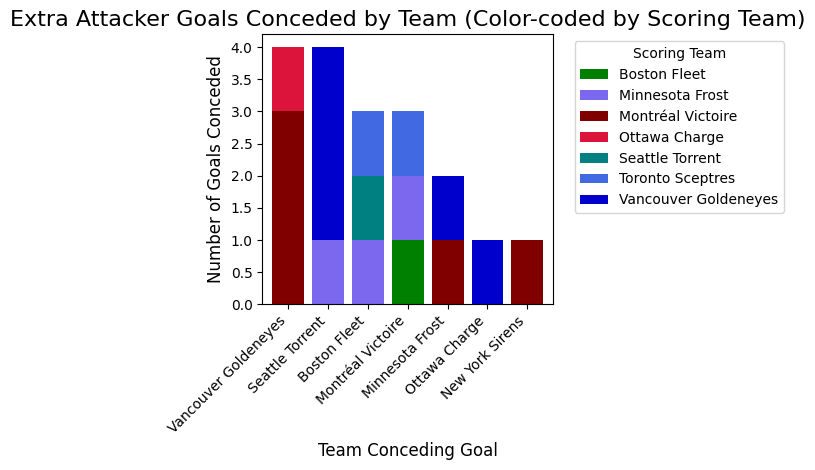

In [ ]:
import matplotlib.pyplot as plt

# Group by goal_against_team_name and goal_team_name to get counts for stacking
stacked_goals_data = s3_extra_attacker_goals.groupby(['goal_against_team_name', 'goal_team_name']).size().unstack(fill_value=0)

# Sort the index (teams that conceded goals) by total goals conceded, for consistency with previous charts
stacked_goals_data['Total Conceded'] = stacked_goals_data.sum(axis=1)
stacked_goals_data = stacked_goals_data.sort_values(by='Total Conceded', ascending=False).drop(columns='Total Conceded')

# Get colors for the scoring teams (columns of stacked_goals_data)
colors_for_stacks = [team_color_map.get(team, 'gray') for team in stacked_goals_data.columns]

plt.figure(figsize=(10, 12)) # Reverted to original figure size
ax = stacked_goals_data.plot.bar(stacked=True, color=colors_for_stacks, width=0.8)

plt.title('Extra Attacker Goals Conceded by Team (Color-coded by Scoring Team)', fontsize=16)
plt.xlabel('Team Conceding Goal', fontsize=12)
plt.ylabel('Number of Goals Conceded', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Reverted legend placement
plt.legend(title='Scoring Team', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Reverted to original tight_layout
plt.show()

# Question: Are teams better at scoring with the extra attacker when they are at home?

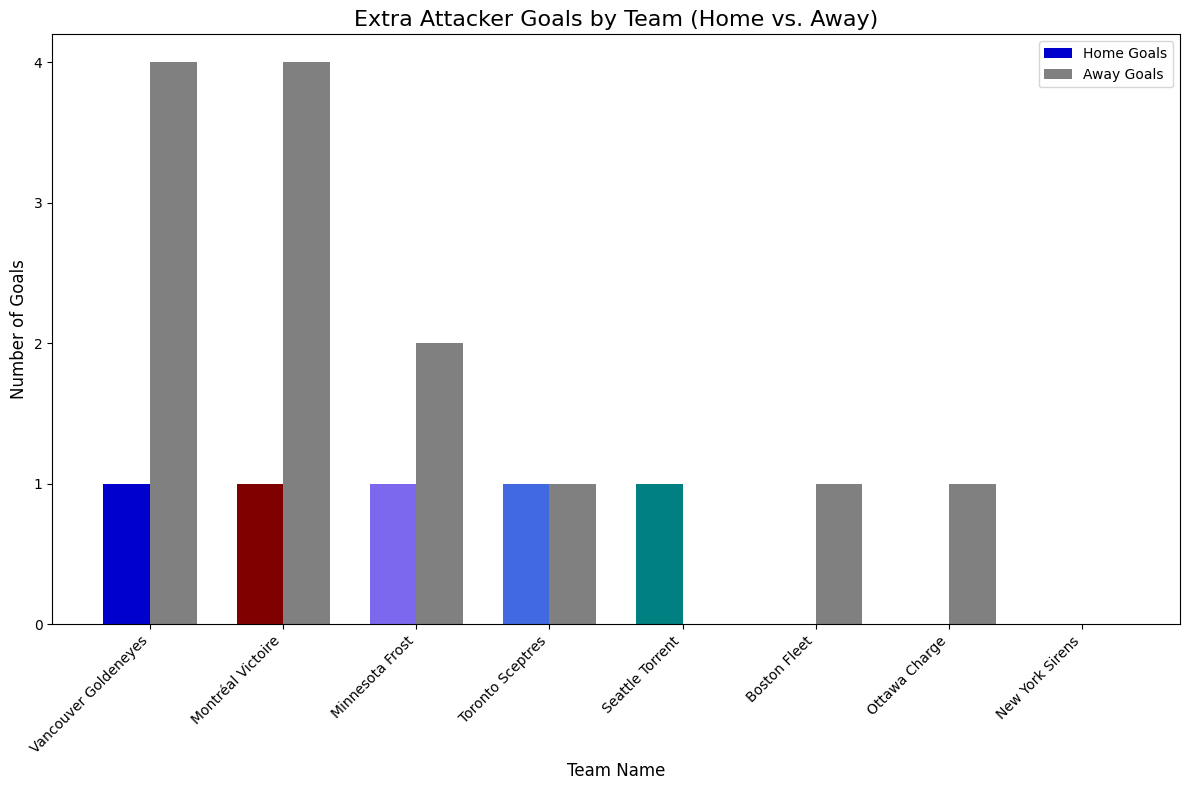

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Determine if the goal was scored at home or away for the scoring team
s3_extra_attacker_goals_copy = s3_extra_attacker_goals.copy()
s3_extra_attacker_goals_copy['location'] = s3_extra_attacker_goals_copy.apply(
    lambda row: 'Home' if row['goal_team_name'] == row['home_team_name'] else 'Away',
    axis=1
)

# Group by team and location, then count goals
goals_by_location = s3_extra_attacker_goals_copy.groupby(['goal_team_name', 'location']).size().unstack(fill_value=0)

# Ensure all teams are present, even if they have no home or away goals
# Use s3_all_goals to get all unique team names from the full dataset for comprehensive representation
all_teams_in_dataset = pd.DataFrame(s3_all_goals['goal_team_name'].unique(), columns=['goal_team_name'])

goals_by_location = pd.merge(all_teams_in_dataset, goals_by_location, on='goal_team_name', how='left').set_index('goal_team_name').fillna(0).astype(int)

# Add 'Home' and 'Away' columns if they don't exist (for teams with no goals in a category)
if 'Home' not in goals_by_location.columns:
    goals_by_location['Home'] = 0
if 'Away' not in goals_by_location.columns:
    goals_by_location['Away'] = 0

# Sort teams by total goals scored (sum of Home and Away)
goals_by_location['Total'] = goals_by_location['Home'] + goals_by_location['Away']
goals_by_location = goals_by_location.sort_values(by='Total', ascending=False).drop(columns='Total')

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.35
num_teams = len(goals_by_location)
indices = np.arange(num_teams)

team_names = goals_by_location.index.tolist()

# Plot 'Home' bars with team colors
home_bars = ax.bar(indices - bar_width/2, goals_by_location['Home'], bar_width,
                   label='Home Goals',
                   color=[team_color_map.get(team, 'gray') for team in team_names])

# Plot 'Away' bars with a gray color
away_bars = ax.bar(indices + bar_width/2, goals_by_location['Away'], bar_width,
                   label='Away Goals',
                   color='gray')

# Set labels and title
ax.set_title('Extra Attacker Goals by Team (Home vs. Away)', fontsize=16)
ax.set_xlabel('Team Name', fontsize=12)
ax.set_ylabel('Number of Goals', fontsize=12)
ax.set_xticks(indices)
ax.set_xticklabels(team_names, rotation=45, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Set y-axis ticks to integers
max_goals = goals_by_location[['Home', 'Away']].max().max() if not goals_by_location.empty else 0
ax.set_yticks(np.arange(0, max_goals + 1, 1))

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

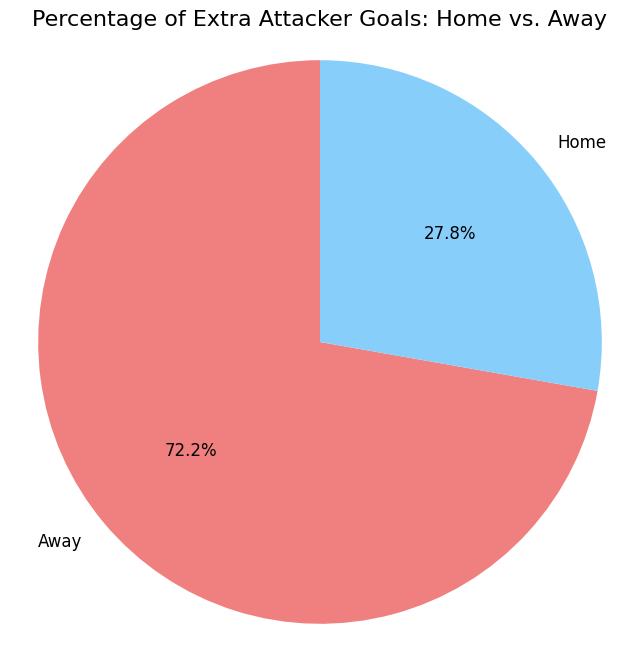

In [ ]:
import matplotlib.pyplot as plt

# Reuse the 'location' logic from the previous cell for s3_extra_attacker_goals
s3_extra_attacker_goals_with_location = s3_extra_attacker_goals.copy()
s3_extra_attacker_goals_with_location['location'] = s3_extra_attacker_goals_with_location.apply(
    lambda row: 'Home' if row['goal_team_name'] == row['home_team_name'] else 'Away',
    axis=1
)

# Count the number of goals by location (Home/Away)
location_counts = s3_extra_attacker_goals_with_location['location'].value_counts()

# Prepare data for the pie chart
labels = location_counts.index
sizes = location_counts.values
colors = ['lightcoral', 'lightskyblue'] # Custom colors for Home and Away
explode = (0, 0)  # Remove 'explode' effect

fig1, ax1 = plt.subplots(figsize=(8, 8))
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=False, startangle=90, textprops={'fontsize': 12}) # Set shadow to False
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Percentage of Extra Attacker Goals: Home vs. Away', fontsize=16)
plt.show()

# Question: which player had the most goals with the extra attacker?

/tmp/ipykernel_1513/1801389001.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s3_extra_attacker_goals['goal_scorer_full_name'] = s3_extra_attacker_goals['goal_scorer.first_name'] + ' ' + s3_extra_attacker_goals['goal_scorer.last_name']


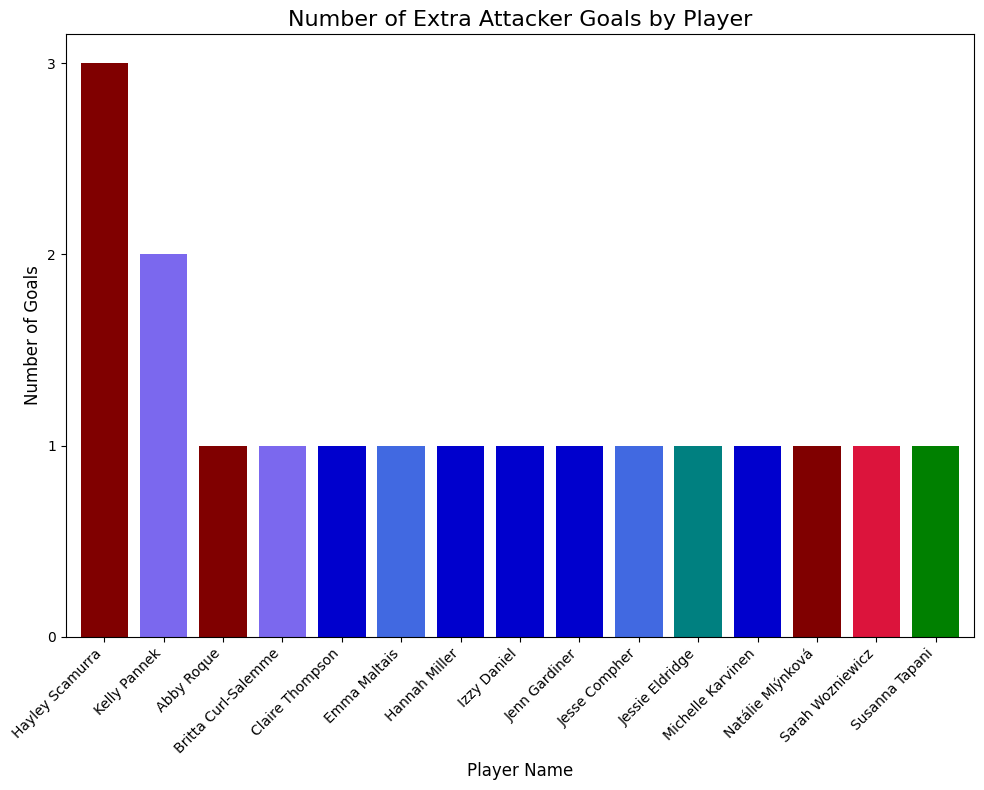

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a full name for each goal scorer
s3_extra_attacker_goals['goal_scorer_full_name'] = s3_extra_attacker_goals['goal_scorer.first_name'] + ' ' + s3_extra_attacker_goals['goal_scorer.last_name']

# Count the number of extra attacker goals per player
player_goal_counts = s3_extra_attacker_goals['goal_scorer_full_name'].value_counts()

# Convert to DataFrame to sort by multiple columns
player_goal_counts_df = player_goal_counts.reset_index()
player_goal_counts_df.columns = ['player_name', 'goals']
# Sort by goals (descending) and then by player_name (ascending)
player_goal_counts_df = player_goal_counts_df.sort_values(by=['goals', 'player_name'], ascending=[False, True])
player_goal_counts = player_goal_counts_df.set_index('player_name')['goals']

# Map colors based on the player's team (if available, otherwise default to gray)
player_team_map = s3_extra_attacker_goals.set_index('goal_scorer_full_name')['goal_team_name'].to_dict()
colors_for_players = [team_color_map.get(player_team_map.get(player, ''), 'gray') for player in player_goal_counts.index]

plt.figure(figsize=(10, 8)) # Adjusted for readability
ax = player_goal_counts.plot.bar(color=colors_for_players, width=0.8)

# Set y-axis ticks to integers
max_goals = player_goal_counts.max()
ax.set_yticks(np.arange(0, max_goals + 1, 1)) # Set ticks from 0 to max_goals in steps of 1

plt.title('Number of Extra Attacker Goals by Player', fontsize=16)
plt.xlabel('Player Name', fontsize=12)
plt.ylabel('Number of Goals', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Question: How many empty net goals were there?

In [ ]:
s3_all_goals[['goal_scorer.first_name', 'empty_net']]

,goal_scorer.first_name,empty_net
0,Kendall,0
1,Ella,0
2,Kiara,0
3,Julia,0
4,Sarah,0
...,...,...
545,Alexa,1
546,Jessie,0
547,Ella,0
548,Haley,0


In [ ]:
s3_empty_net_goals = s3_all_goals[s3_all_goals['empty_net'] == '1'].copy()

In [ ]:
s3_empty_net_goals

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_scorer.first_name,goal_scorer.last_name,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name
13,212,1071,4,229,19:56,19:56,3rd,0,0,"[{'player_id': '229', 'jersey_number': '8', 't...",...,Maja,Nylén Persson,New York Sirens,4,6,False,"Saturday, November 22, 2025",Ottawa Charge,New York Sirens,Ottawa Charge
19,214,1078,3,79,19:50,19:50,3rd,0,0,"[{'player_id': '32', 'jersey_number': '7', 'te...",...,Maggie,Flaherty,Montréal Victoire,5,6,False,"Tuesday, November 25, 2025",Montréal Victoire,New York Sirens,New York Sirens
25,215,1084,5,58,18:12,18:12,3rd,0,0,"[{'player_id': '289', 'jersey_number': '8', 't...",...,Brianne,Jenner,Ottawa Charge,4,6,False,"Wednesday, November 26, 2025",Ottawa Charge,Vancouver Goldeneyes,Vancouver Goldeneyes
38,218,1098,1,15,19:38,19:38,3rd,0,0,"[{'player_id': '12', 'jersey_number': '5', 'te...",...,Alina,Müller,Boston Fleet,5,6,False,"Saturday, November 29, 2025",Toronto Sceptres,Boston Fleet,Toronto Sceptres
44,219,1105,2,20,18:31,18:31,3rd,0,0,"[{'player_id': '167', 'jersey_number': '5', 't...",...,Kendall,Coyne Schofield,Minnesota Frost,5,6,False,"Tuesday, December 2, 2025",Ottawa Charge,Minnesota Frost,Ottawa Charge
53,222,1114,6,76,19:20,19:20,3rd,0,0,"[{'player_id': '67', 'jersey_number': '14', 't...",...,Blayre,Turnbull,Toronto Sceptres,5,6,False,"Thursday, December 4, 2025",Toronto Sceptres,Ottawa Charge,Ottawa Charge
77,229,1139,8,181,18:30,18:30,3rd,0,0,"[{'player_id': '62', 'jersey_number': '2', 'te...",...,Hannah,Bilka,Seattle Torrent,5,6,False,"Wednesday, December 17, 2025",Seattle Torrent,Ottawa Charge,Ottawa Charge
84,230,1146,2,191,19:10,19:10,3rd,0,0,"[{'player_id': '24', 'jersey_number': '2', 'te...",...,Katy,Knoll,Minnesota Frost,5,6,False,"Friday, December 19, 2025",Minnesota Frost,Boston Fleet,Boston Fleet
85,230,1147,2,23,19:52,19:52,3rd,0,0,"[{'player_id': '167', 'jersey_number': '5', 't...",...,Kelly,Pannek,Minnesota Frost,5,6,False,"Friday, December 19, 2025",Minnesota Frost,Boston Fleet,Boston Fleet
97,232,1159,6,65,18:23,18:23,3rd,1,0,"[{'player_id': '68', 'jersey_number': '6', 'te...",...,Jesse,Compher,Toronto Sceptres,5,6,False,"Sunday, December 21, 2025",New York Sirens,Toronto Sceptres,New York Sirens


In [ ]:
s3_empty_net_goals['total_minutes_in_game'] = s3_empty_net_goals.apply(
    lambda row: convert_to_total_minutes(row['period'], row['time']), axis=1
)

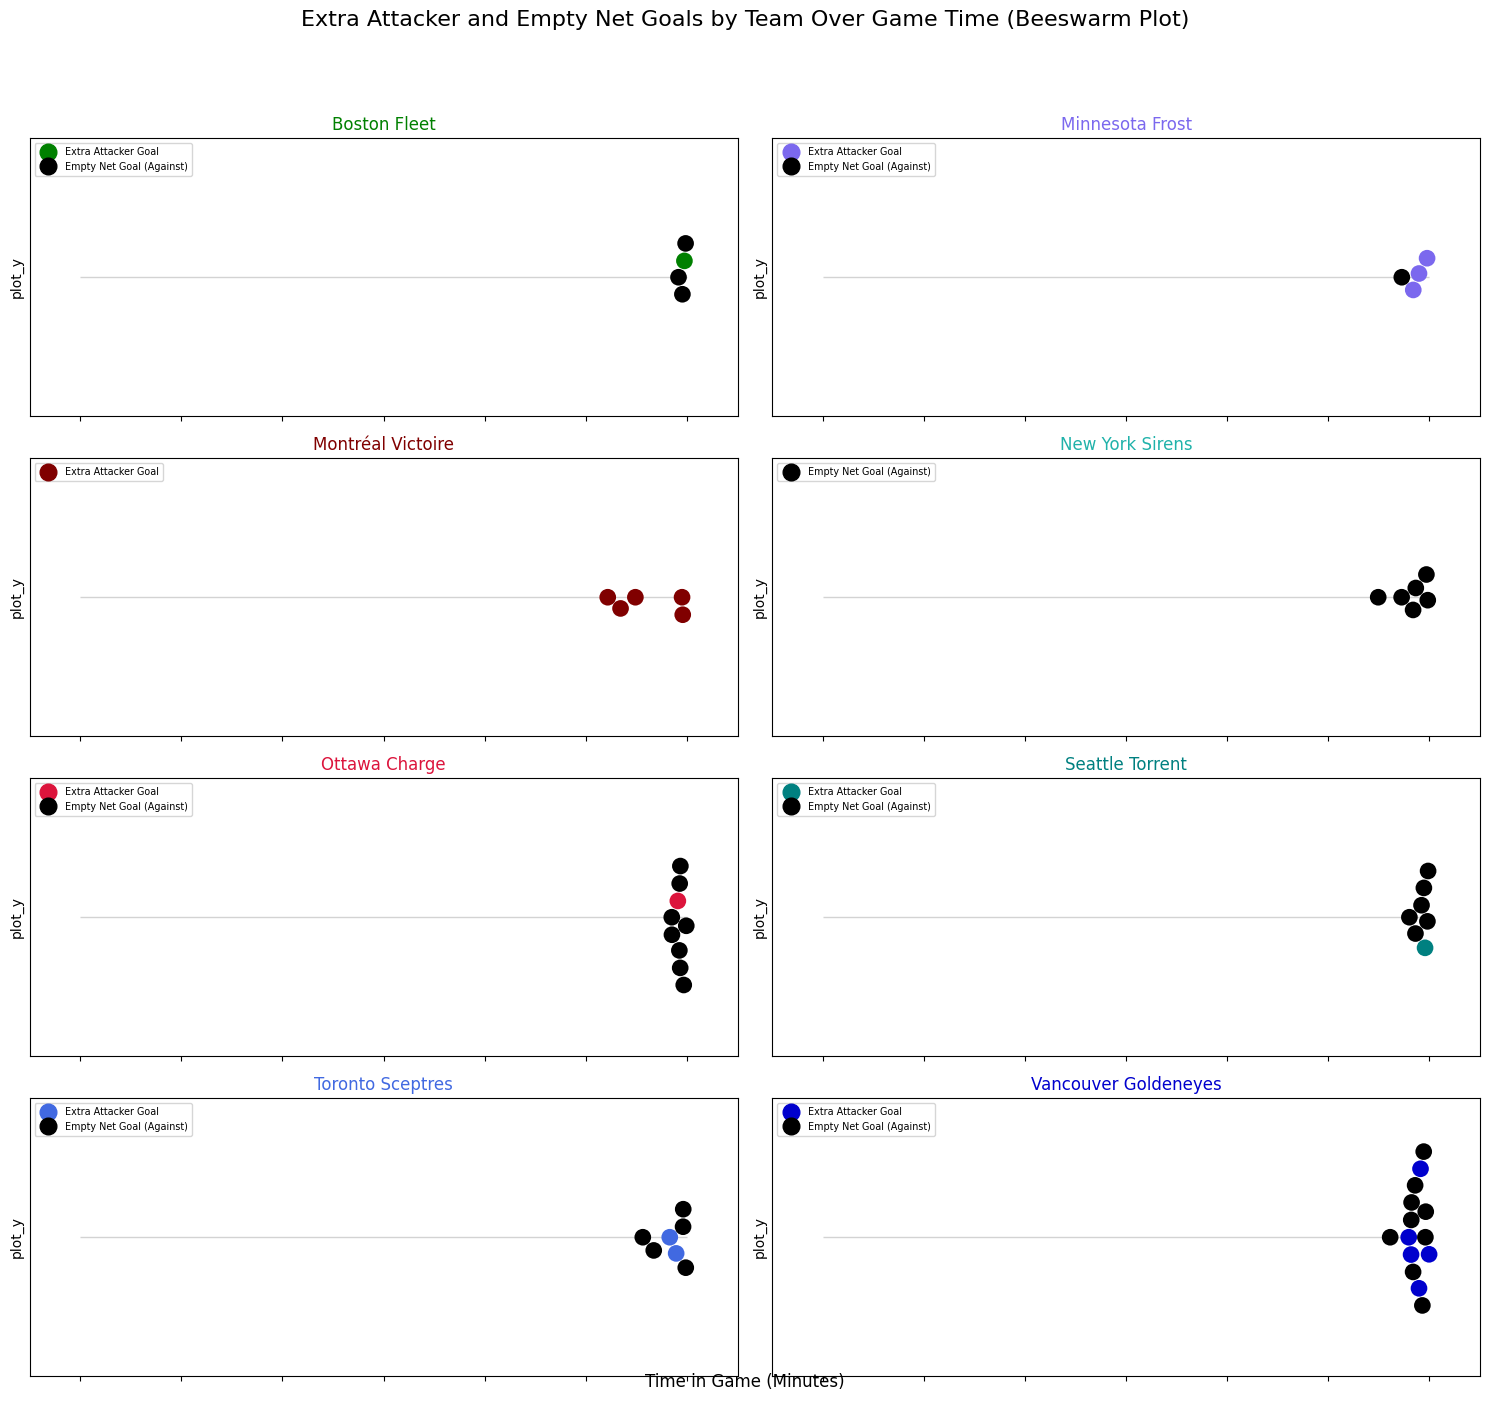

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns # Import seaborn

# Get all unique teams from the goals dataframe
all_teams = sorted(s3_all_goals['goal_team_name'].unique())

# Determine the number of rows and columns for subplots
num_teams = len(all_teams)
num_cols = 2 # Aim for 2 columns
num_rows = (num_teams + num_cols - 1) // num_cols # Calculate rows needed

# Adjusted `sharey=False` because `swarmplot` will adjust y-limits for density.
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3.5 * num_rows), sharex=True, sharey=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

fig.suptitle('Extra Attacker and Empty Net Goals by Team Over Game Time (Beeswarm Plot)', fontsize=16, y=1.02)

# Define a base y-value for the swarmplot to center the points
base_y_value = 0

for i, team_name in enumerate(all_teams):
    ax = axes[i]

    # Filter extra attacker goals for the current team
    team_ea_goals = s3_extra_attacker_goals[s3_extra_attacker_goals['goal_team_name'] == team_name].copy()
    team_ea_goals['goal_type'] = 'Extra Attacker Goal'
    team_ea_goals['plot_y'] = base_y_value # Add a constant y-value for swarmplot

    # Filter empty net goals *against* the current team
    team_en_goals = s3_empty_net_goals[s3_empty_net_goals['goal_against_team_name'] == team_name].copy()
    team_en_goals['goal_type'] = 'Empty Net Goal (Against)'
    team_en_goals['plot_y'] = base_y_value # Add a constant y-value for swarmplot

    # Combine both dataframes for a single swarmplot call
    combined_goals_df = pd.concat([team_ea_goals, team_en_goals])

    team_color_for_title = team_color_map.get(team_name, 'gray')
    ax.set_title(team_name, fontsize=12, color=team_color_for_title)

    # Draw a horizontal line for game time - a reference for the swarmplot points
    ax.hlines(base_y_value, 0, 60, color='lightgray', linestyle='-', linewidth=1, zorder=0)

    # Plot combined goals with swarmplot, using 'hue' to differentiate
    if not combined_goals_df.empty:
        # Define palette for hue based on goal_type
        palette_dict = {
            'Extra Attacker Goal': team_color_map.get(team_name, 'gray'),
            'Empty Net Goal (Against)': 'black'
        }

        sns.swarmplot(
            data=combined_goals_df,
            x='total_minutes_in_game',
            y='plot_y', # Swarm around this y-value
            hue='goal_type', # Differentiate by goal type
            palette=palette_dict, # Apply custom colors
            marker='o', # Use 'o' for all markers, as user preferred for visibility. Swarmplot will handle separation.
            s=12, # Use a consistent size for visibility
            ax=ax,
            zorder=6,
            orient='h' # Explicitly set orientation to horizontal
        )

    ax.set_xlim(-5, 65)
    # The y-limits will be automatically adjusted by swarmplot based on density.
    ax.set_yticks([]) # Hide y-ticks
    ax.set_xlabel('') # Hide x-axis label on subplots
    ax.set_xticks(np.arange(0, 61, 10))
    ax.set_xticklabels([]) # Hide x-tick labels on subplots

    # Custom legend for each subplot
    handles = []
    labels = []

    # Add legend elements for Extra Attacker Goals if present
    if 'Extra Attacker Goal' in combined_goals_df['goal_type'].unique():
        handles.append(plt.Line2D([0], [0], marker='o', color=team_color_map.get(team_name, 'gray'), label='Extra Attacker Goal', linestyle='None', markersize=12))
        labels.append('Extra Attacker Goal')

    # Add legend elements for Empty Net Goals (Against) if present
    if 'Empty Net Goal (Against)' in combined_goals_df['goal_type'].unique():
        handles.append(plt.Line2D([0], [0], marker='o', color='black', label='Empty Net Goal (Against)', linestyle='None', markersize=12))
        labels.append('Empty Net Goal (Against)')

    if handles:
        # Ensure consistent legend order
        sorted_handles_labels = []
        if 'Extra Attacker Goal' in labels:
            idx = labels.index('Extra Attacker Goal')
            sorted_handles_labels.append((handles[idx], labels[idx]))
        if 'Empty Net Goal (Against)' in labels:
            idx = labels.index('Empty Net Goal (Against)')
            sorted_handles_labels.append((handles[idx], labels[idx]))

        ax.legend(handles=[h for h, l in sorted_handles_labels], labels=[l for h, l in sorted_handles_labels], loc='upper left', fontsize='x-small', ncol=1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a common x-label at the bottom of the figure
fig.text(0.5, 0.04, 'Time in Game (Minutes)', ha='center', va='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

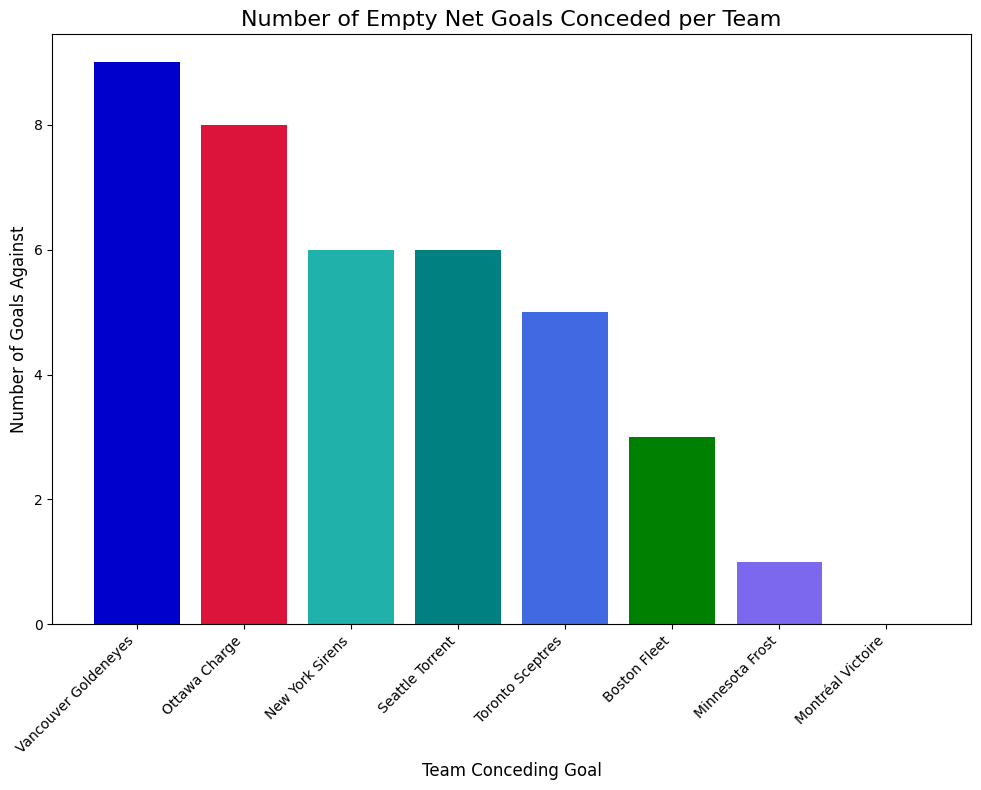

In [ ]:
import matplotlib.pyplot as plt

# Get all unique team names from the full dataset
all_unique_teams = s3_all_goals['goal_team_name'].unique()
all_teams_df = pd.DataFrame({'team_name': all_unique_teams})

# Count the number of empty net goals against each team that conceded at least one
en_goals_against_counts = s3_empty_net_goals['goal_against_team_name'].value_counts().reset_index()
en_goals_against_counts.columns = ['team_name', 'count']

# Merge with all_teams_df to include teams with zero empty net goals conceded
en_goals_against_summary = pd.merge(
    all_teams_df,
    en_goals_against_counts,
    on='team_name',
    how='left'
)

# Fill NaN values (for teams with 0 goals conceded) with 0 and convert to int
en_goals_against_summary['count'] = en_goals_against_summary['count'].fillna(0).astype(int)

# Sort by count (descending) and then by team name (ascending) for consistent order
en_goals_against_summary = en_goals_against_summary.sort_values(by=['count', 'team_name'], ascending=[False, True])

# Get colors for the teams present in en_goals_against_summary
colors_en_against = [team_color_map.get(team, 'gray') for team in en_goals_against_summary['team_name']]

plt.figure(figsize=(10, 8))
plt.bar(en_goals_against_summary['team_name'], en_goals_against_summary['count'], color=colors_en_against, width=0.8)
plt.title('Number of Empty Net Goals Conceded per Team', fontsize=16)
plt.xlabel('Team Conceding Goal', fontsize=12)
plt.ylabel('Number of Goals Against', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

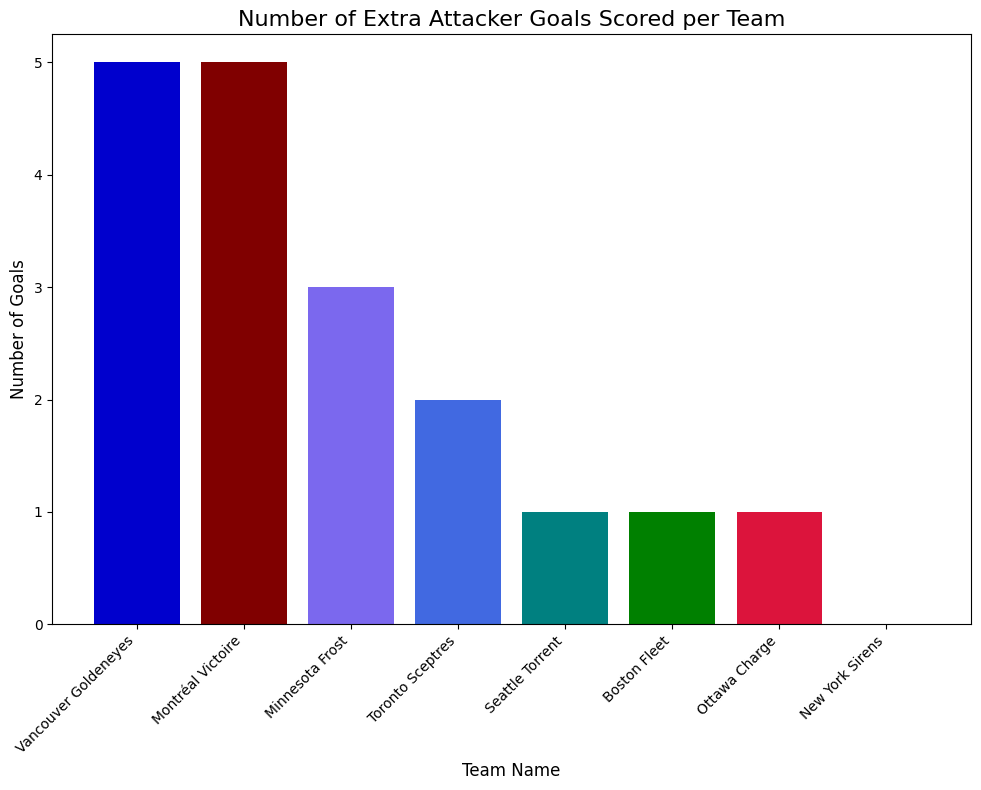

In [ ]:
import matplotlib.pyplot as plt

# Sort the DataFrame to ensure consistent ordering, if not already sorted
extra_attacker_goal_summary = extra_attacker_goal_summary.sort_values(by='extra_attacker_goals_count', ascending=False).reset_index(drop=True)

# Get colors for the teams present in extra_attacker_goal_summary
colors = [team_color_map.get(team, 'gray') for team in extra_attacker_goal_summary['goal_team_name']]

plt.figure(figsize=(10, 8))
plt.bar(extra_attacker_goal_summary['goal_team_name'], extra_attacker_goal_summary['extra_attacker_goals_count'], color=colors, width=0.8)
plt.title('Number of Extra Attacker Goals Scored per Team', fontsize=16)
plt.xlabel('Team Name', fontsize=12)
plt.ylabel('Number of Goals', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
s3_extra_attacker_goals[s3_extra_attacker_goals["goal_team_name"]=="New York Sirens"]

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name,total_minutes_in_game,goal_scorer_full_name


# Goalie pull data

In [ ]:
s3_goalie_changes.head()

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually
0,210,6,2,3:23,None,211,None,Kirk,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False
1,210,6,2,3:30,211,None,Kirk,NaN,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False
2,210,6,3,15:30,None,211,None,Kirk,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False
3,210,6,3,15:48,211,None,Kirk,NaN,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False
4,210,2,3,18:48,None,123,None,Rooney,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False


In [ ]:
import numpy as np

# Apply the function to create the new column
s3_goalie_changes['total_minutes_in_game'] = s3_goalie_changes.apply(
    lambda row: convert_goalie_change_time_to_total_minutes(row['period_id'], row['time']), axis=1
)

s3_goalie_changes.head()

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game
0,210,6,2,3:23,None,211,None,Kirk,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,23.383333
1,210,6,2,3:30,211,None,Kirk,NaN,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,23.500000
2,210,6,3,15:30,None,211,None,Kirk,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,55.500000
3,210,6,3,15:48,211,None,Kirk,NaN,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,55.800000
4,210,2,3,18:48,None,123,None,Rooney,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,58.800000


In [ ]:
len(s3_goalie_changes)

280

In [ ]:
s3_goalie_changes.tail()

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game
275,278,4,3,17:97,NaN,228,None,Osborne,"Thursday, March 5, 2026",New York Sirens,New York Sirens,Boston Fleet,True,58.616667
276,283,1,3,18:49,NaN,41,None,Levy,"Wednesday, March 11, 2026",Seattle Torrent,Boston Fleet,Boston Fleet,True,58.816667
277,302,2,3,18:40,NaN,22,None,Hensley,"Sunday, March 29, 2026",Minnesota Frost,Minnesota Frost,Boston Fleet,True,58.666667
278,303,8,3,18:23,NaN,155,None,Schroeder,"Sunday, March 29, 2026",Seattle Torrent,Seattle Torrent,Ottawa Charge,True,58.383333
279,321,2,3,18:19,NaN,123,None,Rooney,"Sunday, April 19, 2026",Minnesota Frost,Minnesota Frost,Toronto Sceptres,True,58.316667


In [ ]:
def s3_goalie_pulls_verified(df, game_id_to_remove, time_remaining_threshold):
    # Create a copy to avoid modifying the original DataFrame directly
    filtered_df = df.copy()

    # Filter out rows where game_id matches and time_remaining is less than the threshold
    # Note: the user specified 'time before input', which translates to 'time_remaining' being greater than the threshold
    # If 'time before input' means actual game time, then 'time_remaining' would be greater
    # Re-interpreting 'time before input' as 'time_remaining' being greater than the threshold (meaning earlier pull)
    # Example: If threshold is 5 minutes, and a pull was at 6 minutes remaining (time_remaining=6), it's 'before' 5 minutes remaining.
    # However, given the context of removing 'sus' game IDs, it's more likely to remove pulls that happen 'too early' in terms of game clock.
    # So, I'll filter out pulls that have a time_remaining *greater than or equal to* the threshold, as they happened earlier than desired.
    # This matches the previous logic of filtering out early pulls.

    # The user states 'time before input', which in hockey time remaining, means a higher time remaining value.
    # For example, 10 minutes remaining is 'before' 5 minutes remaining.
    # So, we want to remove rows where game_id matches AND time_remaining is >= time_remaining_threshold
    rows_to_remove_condition = (filtered_df['game_id'] == game_id_to_remove) & \
                               (filtered_df['time_remaining'] >= time_remaining_threshold)

    filtered_df = filtered_df[~rows_to_remove_condition]
    return filtered_df

### Example Usage of `s3_goalie_pulls_verified`

Let's assume you want to remove goalie pulls from `game_id` 210 that occurred when there was 5 or more minutes remaining in the game (i.e., `time_remaining >= 5`).

In [ ]:
s3_goalie_pulls = s3_goalie_changes[s3_goalie_changes['goalie_in_id'].isna()]
s3_goalie_pulls['time_remaining'] = 60 - s3_goalie_pulls['total_minutes_in_game']

#filter out goalie pulls before 10 mins
s3_goalie_pulls = s3_goalie_pulls[s3_goalie_pulls['total_minutes_in_game'] >= 50]

#filter out goalie pulls at end of game
s3_goalie_pulls = s3_goalie_pulls[s3_goalie_pulls['total_minutes_in_game'] < 60]


/tmp/ipykernel_1513/4178206635.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s3_goalie_pulls['time_remaining'] = 60 - s3_goalie_pulls['total_minutes_in_game']


game ids that are sus:

*   210 - delayed penalty
*   251 - delayed penalty
*   260 - delayed penalty
*   290 - delayed penalty
*   307 - delayed penalty
*   324 - delayed penalty




In [ ]:
# Original DataFrame for comparison (only showing relevant columns for game_id 210)
display(s3_goalie_pulls[s3_goalie_pulls['game_id'] == 324])

verified_goalie_pulls = s3_goalie_pulls.copy()

# Modify data for games 210 and 251
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=210, time_remaining_threshold=4)
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=251, time_remaining_threshold=7)
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=260, time_remaining_threshold=1.79)
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=290, time_remaining_threshold=8.7)
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=307, time_remaining_threshold=7.7)
verified_goalie_pulls = s3_goalie_pulls_verified(verified_goalie_pulls, game_id_to_remove=324, time_remaining_threshold=8)
display(verified_goalie_pulls[verified_goalie_pulls['game_id'] == 324])

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game,time_remaining
252,324,1,3,11:55,None,6,None,Frankel,"Wednesday, April 22, 2026",Boston Fleet,NaN,Ottawa Charge,False,51.916667,8.083333


,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game,time_remaining


In [ ]:
s3_first_goalie_pulls = verified_goalie_pulls.loc[verified_goalie_pulls.groupby('game_id')['total_minutes_in_game'].idxmin()]
s3_first_goalie_pulls.head()

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game,time_remaining
4,210,2,3,18:48,None,123,None,Rooney,"Friday, November 21, 2025",Minnesota Frost,NaN,Toronto Sceptres,False,58.800000,1.200000
5,211,9,3,17:53,None,59,None,Maschmeyer,"Friday, November 21, 2025",Vancouver Goldeneyes,NaN,Seattle Torrent,False,57.883333,2.116667
9,212,5,3,17:10,None,222,None,Philips,"Saturday, November 22, 2025",Ottawa Charge,NaN,New York Sirens,False,57.166667,2.833333
12,213,3,3,17:09,None,28,None,Desbiens,"Sunday, November 23, 2025",Boston Fleet,NaN,Montréal Victoire,False,57.150000,2.850000
17,214,4,3,15:39,None,228,None,Osborne,"Tuesday, November 25, 2025",Montréal Victoire,NaN,New York Sirens,False,55.650000,4.350000


In [ ]:
len(s3_first_goalie_pulls)

82

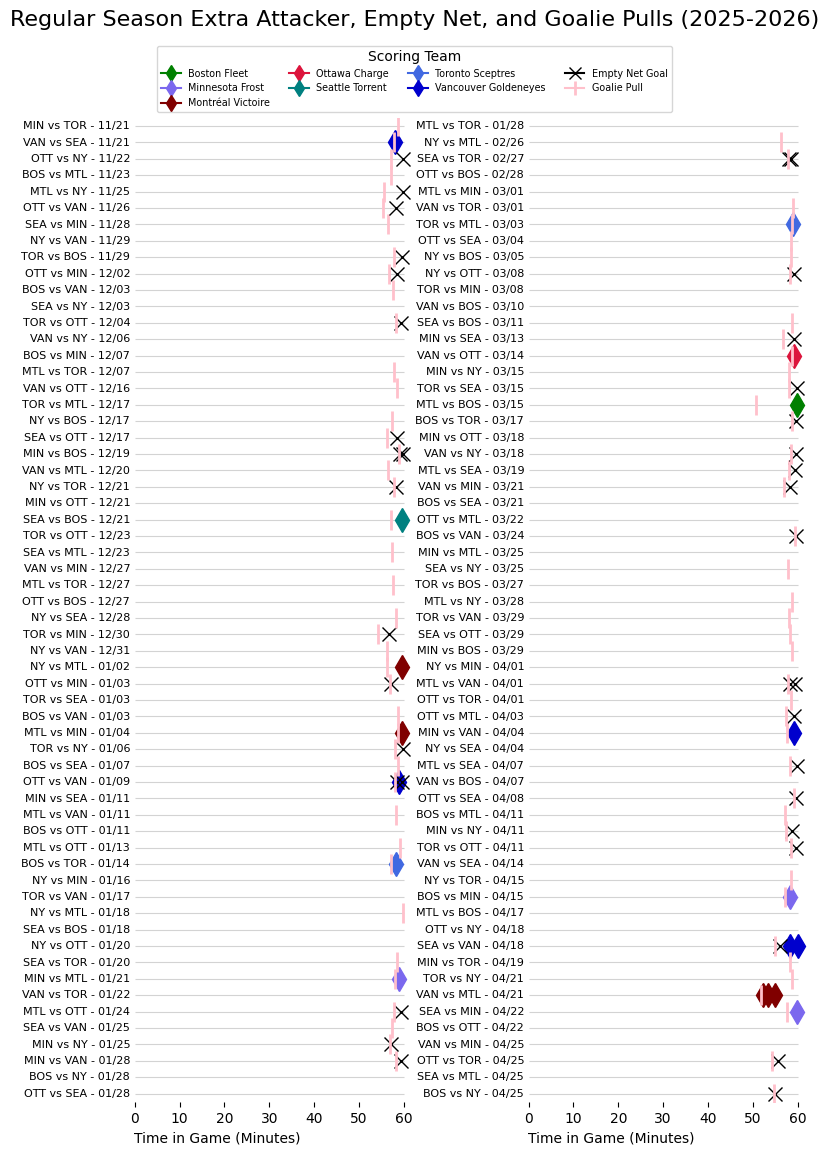

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# marker = '|'
markersize = 12
linewidth = 3

# Helper function to plot on a given ax with compact vertical spacing
def _plot_extra_attacker_goals_single_axis_compact(
    ax, games_metadata_df_subset, chart_title,
    extra_attacker_goals_df, empty_net_goals_df, goalie_pulls_df, # Added goalie_pulls_df
    team_color_map, team_acronym_map, markersize=20,
    label_fontsize=8, vertical_spacing_factor=0.75,  marker='|'):

    # Sort games_metadata_df_subset by date in descending order (latest games at bottom)
    games_metadata_df_subset = games_metadata_df_subset.sort_values(by='game_date_dt', ascending=False).reset_index(drop=True)

    # Remove the plot border for this specific ax
    for spine in ax.spines.values():
        spine.set_visible(False)

    num_games = len(games_metadata_df_subset)
    # y_pos for each game line, scaled by the vertical_spacing_factor
    y_pos = np.arange(num_games) * vertical_spacing_factor

    # Plot for each game
    for i, game_row in games_metadata_df_subset.iterrows():
        game_id = game_row['game_id']
        home_team = game_row['home_team_name']
        away_team = game_row['away_team_name']
        game_date_formatted = game_row['game_date_dt'].strftime('%m/%d') # Format date to MM/DD

        # Use acronyms for labels
        home_team_acronym = team_acronym_map.get(home_team, home_team)
        away_team_acronym = team_acronym_map.get(away_team, away_team)
        label_text = f"{home_team_acronym} vs {away_team_acronym} - {game_date_formatted}"
        # Position label to the left of the 0-minute mark, right-aligned to be close to the line
        ax.text(-1, y_pos[i], label_text, va='center', ha='right', fontsize=label_fontsize) # Adjusted x-coordinate to be -1, right-aligned

        # Horizontal line representing 60 minutes of regulation play (0 to 60 minutes)
        ax.hlines(y_pos[i], 0, 60, color='lightgray', linestyle='solid', linewidth=0.8)

        # Filter extra attacker goals for the current game
        game_extra_attacker_goals = extra_attacker_goals_df[extra_attacker_goals_df['game_id'] == game_id]

        # Plot dots for each extra attacker goal if any exist for this game
        for _, goal_row in game_extra_attacker_goals.iterrows():
            total_minutes = goal_row['total_minutes_in_game']
            scoring_team = goal_row['goal_team_name']
            color = team_color_map.get(scoring_team, 'gray')
            ax.plot(total_minutes, y_pos[i], marker, color=color, markersize=markersize, zorder=5)

        # Filter empty net goals for the current game
        game_empty_net_goals = empty_net_goals_df[empty_net_goals_df['game_id'] == game_id]
        # Plot empty net goals with a black 'x' marker
        for _, goal_row in game_empty_net_goals.iterrows():
            total_minutes = goal_row['total_minutes_in_game']
            ax.plot(total_minutes, y_pos[i], 'x', color='black', markersize=10, zorder=6) # Plot with 'x' marker, black color

        # Filter goalie pulls for the current game
        game_goalie_pulls = goalie_pulls_df[goalie_pulls_df['game_id'] == game_id]
        # Plot goalie pulls with a blue '|' marker
        for _, pull_row in game_goalie_pulls.iterrows():
            total_minutes = pull_row['total_minutes_in_game']
            ax.plot(total_minutes, y_pos[i], '|', color='pink', markersize=15, markeredgewidth=2, zorder=6) # Plot with '|' marker, blue color

    ax.set_xlabel('Time in Game (Minutes)', fontsize=10)
    ax.set_yticks([]) # Hide y-ticks as labels are custom
    # Adjusted x-limits to encompass labels more tightly and give more visual space to the 0-60 range
    ax.set_xlim(-25, 62)
    ax.set_xticks(np.arange(0, 61, 10)) # Set x-ticks to be non-negative, covering 0-60
    ax.set_ylim(-0.5 * vertical_spacing_factor, (num_games - 0.5) * vertical_spacing_factor) # Adjust y-limits to fit all game lines

# Main plotting function for the new request with compact spacing
def plot_extra_attacker_goals_halves_and_playoffs_compact(
    regular_season_metadata, playoffs_metadata,
    extra_attacker_goals_df, empty_net_goals_df, goalie_pulls_df, # Added goalie_pulls_df
    team_color_map, team_acronym_map,
    vertical_spacing_factor=0.75, marker='|'):

    # Ensure game_date is datetime for sorting
    regular_season_metadata_copy = regular_season_metadata.copy()
    regular_season_metadata_copy['game_date_dt'] = pd.to_datetime(regular_season_metadata_copy['game_date'])
    sorted_regular_season = regular_season_metadata_copy.sort_values(by='game_date_dt', ascending=True).reset_index(drop=True)

    # Split regular season into two halves
    midpoint = len(sorted_regular_season) // 2
    first_half_season = sorted_regular_season.iloc[:midpoint]
    second_half_season = sorted_regular_season.iloc[midpoint:]

    # --- Plot Regular Season Halves in 2 columns ---
    # Increased width to make the 0-60 lines appear longer, while keeping height for readability
    # Scale figure height based on the vertical_spacing_factor to maintain aspect ratio with reduced spacing
    fig_rs, axes_rs = plt.subplots(1, 2, figsize=(8, 12), sharey=False) # Changed height to 12 as requested
    fig_rs.suptitle('Regular Season Extra Attacker, Empty Net, and Goalie Pulls (2025-2026)', fontsize=16, y=0.99) # Overall title, adjusted y-position to be higher

    # Plot first half
    _plot_extra_attacker_goals_single_axis_compact(axes_rs[0], first_half_season, 'First Half',
                                                    extra_attacker_goals_df, empty_net_goals_df, goalie_pulls_df, # Pass empty_net_goals_df and goalie_pulls_df
                                                    team_color_map, team_acronym_map,
                                                    markersize=markersize, label_fontsize=8,
                                                    vertical_spacing_factor=vertical_spacing_factor, marker=marker)
    # Plot second half
    _plot_extra_attacker_goals_single_axis_compact(axes_rs[1], second_half_season, 'Second Half',
                                                    extra_attacker_goals_df, empty_net_goals_df, goalie_pulls_df, # Pass empty_net_goals_df and goalie_pulls_df
                                                    team_color_map, team_acronym_map,
                                                    markersize=markersize, label_fontsize=8,
                                                    vertical_spacing_factor=vertical_spacing_factor, marker=marker)

    # Create a single legend for both regular season plots
    legend_elements = []
    unique_scoring_teams_rs = extra_attacker_goals_df[extra_attacker_goals_df['game_id'].isin(regular_season_metadata['game_id'])]['goal_team_name'].unique()
    for team in sorted(unique_scoring_teams_rs):
        color = team_color_map.get(team, 'gray')
        legend_elements.append(plt.Line2D([0], [0], marker=marker, color=color, label=team, markersize=8)) # Reduced markersize

    # Add empty net goals to the legend
    legend_elements.append(plt.Line2D([0], [0], marker='x', color='black', label='Empty Net Goal', markersize=8)) # Reduced markersize

    # Add goalie pulls to the legend
    legend_elements.append(plt.Line2D([0], [0], marker='|', color='pink', label='Goalie Pull', markersize=10, markeredgewidth=2)) # Add goalie pull legend

    if legend_elements:
        # Move legend to the top, below the suptitle, with slightly adjusted y and reduced borderaxespad
        fig_rs.legend(handles=legend_elements, title="Scoring Team", bbox_to_anchor=(0.5, 0.96), loc='upper center', ncol=4, borderaxespad=0., fontsize='x-small') # Adjusted bbox_to_anchor y to 0.96 and added fontsize='x-small'

    # Replaced tight_layout with subplots_adjust for finer control over spacing, adjusted top for legend/title space
    fig_rs.subplots_adjust(left=0.01, right=0.99, bottom=0.08, top=0.90, wspace=0.01) # Adjusted top to 0.90
    plt.show()

# Call the new plotting function with existing dataframes and reduced vertical spacing
plot_extra_attacker_goals_halves_and_playoffs_compact(
    regular_season_games_metadata,
    playoffs_games_metadata,
    s3_extra_attacker_goals,
    s3_empty_net_goals, # Pass s3_empty_net_goals here
    s3_first_goalie_pulls, # Pass s3_goalie_pulls here
    team_color_map,
    team_acronym_map,
    vertical_spacing_factor=0.75, # Adjust this value to control spacing
    marker='d',
)

Average time remaining when goalie was first pulled: 2.44 minutes


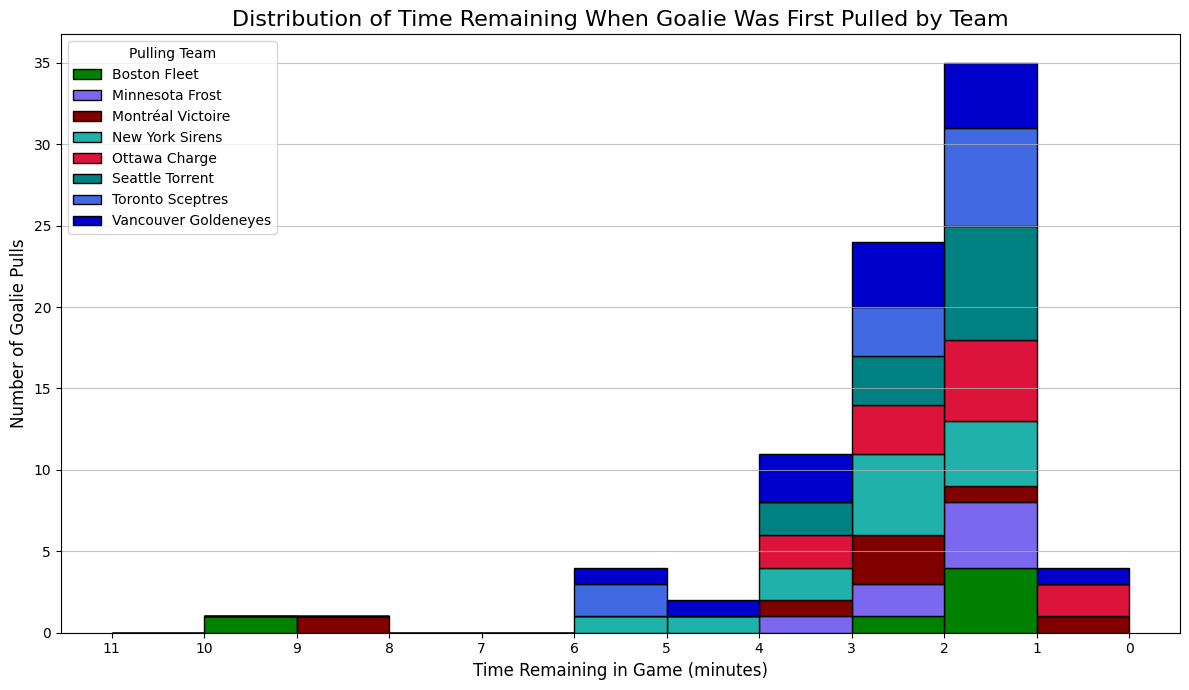

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Calculate time remaining in the game when the goalie was pulled (already done)
s3_first_goalie_pulls['time_remaining'] = 60 - s3_first_goalie_pulls['total_minutes_in_game']

# Calculate the average time remaining
average_time_remaining = s3_first_goalie_pulls['time_remaining'].mean()
print(f"Average time remaining when goalie was first pulled: {average_time_remaining:.2f} minutes")

# Ensure 'team_id' is numeric before mapping to team_name_map
s3_first_goalie_pulls['team_id'] = pd.to_numeric(s3_first_goalie_pulls['team_id'], errors='coerce').astype('Int64')

# Add a column for the name of the team that pulled the goalie
s3_first_goalie_pulls['pulling_team_name'] = s3_first_goalie_pulls['team_id'].map(team_name_map)

# Prepare data for stacked histogram
# Get unique pulling teams, dropping any NaN values, and sort them for consistent plotting and legend order
unique_pulling_teams = sorted(s3_first_goalie_pulls['pulling_team_name'].dropna().unique())

# Create a list of 'time_remaining' arrays, one for each team
time_remaining_by_team = []
colors_for_hist = []

for team in unique_pulling_teams:
    team_data = s3_first_goalie_pulls[s3_first_goalie_pulls['pulling_team_name'] == team]['time_remaining']
    time_remaining_by_team.append(team_data)
    colors_for_hist.append(team_color_map.get(team, 'gray')) # Use team_color_map

# Plotting the stacked histogram
plt.figure(figsize=(12, 7))
# Bins should cover the range of 'time_remaining' with 1-minute intervals.
# Adding +2 to the max ensures the last bin includes the maximum value. For example, if max is 10.5, bins go up to 12.
counts, bins, patches = plt.hist(time_remaining_by_team, bins=np.arange(0, s3_first_goalie_pulls['time_remaining'].max() + 2, 1),
                                   stacked=True, edgecolor='black', color=colors_for_hist, label=unique_pulling_teams)

plt.title('Distribution of Time Remaining When Goalie Was First Pulled by Team', fontsize=16)
plt.xlabel('Time Remaining in Game (minutes)', fontsize=12)
plt.ylabel('Number of Goalie Pulls', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# Invert the x-axis to have 10 on the left and 0 on the right
plt.gca().invert_xaxis()
# Set x-ticks to match the bin edges for clarity, starting from 0 up to max time remaining
plt.xticks(np.arange(0, s3_first_goalie_pulls['time_remaining'].max() + 2, 1))

plt.legend(title='Pulling Team', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
s3_first_goalie_pulls['time_remaining'] = 60 - s3_first_goalie_pulls['total_minutes_in_game']

# Define the desired order of columns. The remaining columns will be appended at the end.
desired_columns = [
    'time_remaining',
    'game_date',
    'home_team_name',
    'away_team_name'
]

# Get the current columns of the DataFrame
current_columns = s3_first_goalie_pulls.columns.tolist()

# Identify columns that are not in the desired_columns list and are not 'time_remaining'
remaining_columns = [col for col in current_columns if col not in desired_columns and col != 'time_remaining']

# Create the new column order, ensuring no duplicates and correct placement
new_column_order = desired_columns + remaining_columns

# Reindex the DataFrame with the new column order
s3_first_goalie_pulls = s3_first_goalie_pulls.reindex(columns=new_column_order)


In [ ]:
s3_first_goalie_pulls

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name
4,1.200000,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,210,2,3,18:48,None,123,None,Rooney,NaN,False,58.800000,Minnesota Frost
5,2.116667,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,211,9,3,17:53,None,59,None,Maschmeyer,NaN,False,57.883333,Vancouver Goldeneyes
9,2.833333,"Saturday, November 22, 2025",Ottawa Charge,New York Sirens,212,5,3,17:10,None,222,None,Philips,NaN,False,57.166667,Ottawa Charge
12,2.850000,"Sunday, November 23, 2025",Boston Fleet,Montréal Victoire,213,3,3,17:09,None,28,None,Desbiens,NaN,False,57.150000,Montréal Victoire
17,4.350000,"Tuesday, November 25, 2025",Montréal Victoire,New York Sirens,214,4,3,15:39,None,228,None,Osborne,NaN,False,55.650000,New York Sirens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240,1.333333,"Tuesday, April 21, 2026",Toronto Sceptres,New York Sirens,322,4,3,18:40,None,228,None,Osborne,NaN,False,58.666667,New York Sirens
244,8.183333,"Tuesday, April 21, 2026",Vancouver Goldeneyes,Montréal Victoire,323,3,3,11:49,None,48,None,Abstreiter,NaN,False,51.816667,Montréal Victoire
256,2.266667,"Wednesday, April 22, 2026",Seattle Torrent,Minnesota Frost,325,2,3,17:44,None,22,None,Hensley,NaN,False,57.733333,Minnesota Frost
261,5.716667,"Saturday, April 25, 2026",Ottawa Charge,Toronto Sceptres,328,6,3,14:17,None,211,None,Kirk,NaN,False,54.283333,Toronto Sceptres


In [ ]:
display(s3_first_goalie_pulls.sort_values(by='time_remaining', ascending=False).head())

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name
148,9.233333,"Sunday, March 15, 2026",Montréal Victoire,Boston Fleet,286,1,3,10:46,None,6,None,Frankel,NaN,False,50.766667,Boston Fleet
244,8.183333,"Tuesday, April 21, 2026",Vancouver Goldeneyes,Montréal Victoire,323,3,3,11:49,None,48,None,Abstreiter,NaN,False,51.816667,Montréal Victoire
59,5.750000,"Tuesday, December 30, 2025",Toronto Sceptres,Minnesota Frost,241,6,3,14:15,None,211,None,Kirk,NaN,False,54.250000,Toronto Sceptres
261,5.716667,"Saturday, April 25, 2026",Ottawa Charge,Toronto Sceptres,328,6,3,14:17,None,211,None,Kirk,NaN,False,54.283333,Toronto Sceptres
264,5.266667,"Saturday, April 25, 2026",Boston Fleet,New York Sirens,329,4,3,14:44,None,282,None,Shanahan,NaN,False,54.733333,New York Sirens


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D # Import Line2D for custom legend handles

def visualize_single_game_events(game_id,
                                  extra_attacker_goals_df,
                                  empty_net_goals_df,
                                  goalie_pulls_df,
                                  games_metadata_df,
                                  team_color_map,
                                  team_acronym_map):

    # Filter data for the specific game_id
    game_ea_goals = extra_attacker_goals_df[extra_attacker_goals_df['game_id'] == game_id]
    game_en_goals = empty_net_goals_df[empty_net_goals_df['game_id'] == game_id]
    game_goalie_pulls = goalie_pulls_df[goalie_pulls_df['game_id'] == game_id]
    game_info = games_metadata_df[games_metadata_df['game_id'] == game_id]

    if game_info.empty:
        print(f"No metadata found for Game ID: {game_id}")
        return

    game_row = game_info.iloc[0]
    home_team = game_row['home_team_name']
    away_team = game_row['away_team_name']
    game_date = pd.to_datetime(game_row['game_date']).strftime('%Y-%m-%d') # Format date for title
    home_team_acronym = team_acronym_map.get(home_team, home_team)
    away_team_acronym = team_acronym_map.get(away_team, away_team)

    title_str = f"Game {game_id}: {home_team_acronym} vs {away_team_acronym} ({game_date})"

    fig, ax = plt.subplots(figsize=(12, 2)) # Wider figure for better time axis visibility

    # Plot the 0-60 minute timeline
    ax.hlines(0, 0, 60, color='lightgray', linestyle='solid', linewidth=2)

    # Plot extra attacker goals
    for _, goal_row in game_ea_goals.iterrows():
        total_minutes = goal_row['total_minutes_in_game']
        scoring_team = goal_row['goal_team_name']
        color = team_color_map.get(scoring_team, 'gray')
        ax.plot(total_minutes, 0, 'd', color=color, markersize=15, zorder=5)

    # Plot empty net goals
    for _, goal_row in game_en_goals.iterrows():
        total_minutes = goal_row['total_minutes_in_game']
        ax.plot(total_minutes, 0, 'x', color='black', markersize=15, zorder=6)

    # Plot goalie pulls
    for _, pull_row in game_goalie_pulls.iterrows():
        total_minutes = pull_row['total_minutes_in_game']
        ax.plot(total_minutes, 0, '|', color='orange', markersize=18, markeredgewidth=2, zorder=7)

    ax.set_title(title_str, fontsize=14)
    ax.set_xlabel('Time in Game (Minutes)', fontsize=12)
    ax.set_yticks([]) # Hide y-axis
    ax.set_xlim(-2, 62) # Give a little padding
    ax.set_xticks(np.arange(0, 61, 10))
    ax.set_ylim(-0.5, 0.5) # Keep the line centered

    # Create custom legend handles
    legend_elements = [
        Line2D([0], [0], marker='d', color='gray', label='Extra Attacker Goal', markersize=10),
        Line2D([0], [0], marker='x', color='black', label='Empty Net Goal', markersize=10),
        Line2D([0], [0], marker='|', color='orange', label='Goalie Pull', markersize=15, markeredgewidth=2)
    ]

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, ncol=1)

    plt.tight_layout()
    plt.show()

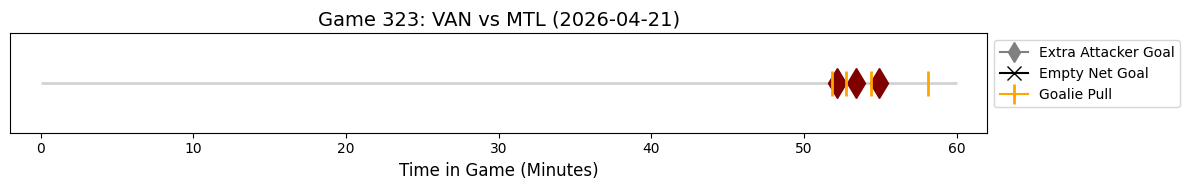

In [ ]:
visualize_single_game_events(
    game_id=323, # Example game ID
    extra_attacker_goals_df=s3_extra_attacker_goals,
    empty_net_goals_df=s3_empty_net_goals,
    goalie_pulls_df=verified_goalie_pulls,
    games_metadata_df=games_metadata,
    team_color_map=team_color_map,
    team_acronym_map=team_acronym_map
)

In [ ]:
s3_first_goalie_pulls.to_csv('s3_first_goalie_pulls.csv', index=False)

In [ ]:
s3_first_goalie_pulls.tail()

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name
240,1.333333,"Tuesday, April 21, 2026",Toronto Sceptres,New York Sirens,322,4,3,18:40,None,228,None,Osborne,NaN,False,58.666667,New York Sirens
244,8.183333,"Tuesday, April 21, 2026",Vancouver Goldeneyes,Montréal Victoire,323,3,3,11:49,None,48,None,Abstreiter,NaN,False,51.816667,Montréal Victoire
256,2.266667,"Wednesday, April 22, 2026",Seattle Torrent,Minnesota Frost,325,2,3,17:44,None,22,None,Hensley,NaN,False,57.733333,Minnesota Frost
261,5.716667,"Saturday, April 25, 2026",Ottawa Charge,Toronto Sceptres,328,6,3,14:17,None,211,None,Kirk,NaN,False,54.283333,Toronto Sceptres
264,5.266667,"Saturday, April 25, 2026",Boston Fleet,New York Sirens,329,4,3,14:44,None,282,None,Shanahan,NaN,False,54.733333,New York Sirens


In [ ]:
s3_extra_attacker_goals.to_csv('s3_extra_attacker_goals.csv', index=False)

In [ ]:
s3_empty_net_goals.to_csv('s3_empty_net_goals.csv', index=False)

In [ ]:
s3_extra_attacker_goals_agg = s3_extra_attacker_goals.groupby('game_id')['id'].apply(list).reset_index(name='extra_attacker_goals')
s3_empty_net_goals_agg = s3_empty_net_goals.groupby('game_id')['id'].apply(list).reset_index(name='empty_net_goals')

# Merge extra attacker goals into s3_first_goalie_pulls
s3_first_goalie_pulls_merged = pd.merge(
    s3_first_goalie_pulls,
    s3_extra_attacker_goals_agg,
    on='game_id',
    how='left'
)

# Merge empty net goals into the combined dataframe
s3_first_goalie_pulls_merged = pd.merge(
    s3_first_goalie_pulls_merged,
    s3_empty_net_goals_agg,
    on='game_id',
    how='left'
)

# Fill NaN values in the new list columns with empty lists
s3_first_goalie_pulls_merged['extra_attacker_goals'] = s3_first_goalie_pulls_merged['extra_attacker_goals'].apply(lambda x: x if isinstance(x, list) else [])
s3_first_goalie_pulls_merged['empty_net_goals'] = s3_first_goalie_pulls_merged['empty_net_goals'].apply(lambda x: x if isinstance(x, list) else [])

# Compute boolean columns
s3_first_goalie_pulls_merged['scored_extra_attacker_goal'] = s3_first_goalie_pulls_merged['extra_attacker_goals'].apply(lambda x: len(x) > 0)
s3_first_goalie_pulls_merged['scored_empty_net_goal'] = s3_first_goalie_pulls_merged['empty_net_goals'].apply(lambda x: len(x) > 0)

# Display the head of the resulting dataframe with the new columns
display(s3_first_goalie_pulls_merged.head())

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name,extra_attacker_goals,empty_net_goals,scored_extra_attacker_goal,scored_empty_net_goal
0,1.200000,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,210,2,3,18:48,None,123,None,Rooney,NaN,False,58.800000,Minnesota Frost,[],[],False,False
1,2.116667,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,211,9,3,17:53,None,59,None,Maschmeyer,NaN,False,57.883333,Vancouver Goldeneyes,[1066],[],True,False
2,2.833333,"Saturday, November 22, 2025",Ottawa Charge,New York Sirens,212,5,3,17:10,None,222,None,Philips,NaN,False,57.166667,Ottawa Charge,[],[1071],False,True
3,2.850000,"Sunday, November 23, 2025",Boston Fleet,Montréal Victoire,213,3,3,17:09,None,28,None,Desbiens,NaN,False,57.150000,Montréal Victoire,[],[],False,False
4,4.350000,"Tuesday, November 25, 2025",Montréal Victoire,New York Sirens,214,4,3,15:39,None,228,None,Osborne,NaN,False,55.650000,New York Sirens,[],[1078],False,True


In [ ]:
s3_first_goalie_pulls_merged.to_csv('s3_goalie_pulls_with_goals.csv', index=False)

In [ ]:
game_ids_with_goalie_pulls = s3_first_goalie_pulls['game_id'].unique()
extra_attacker_goals_without_goalie_pulls = s3_extra_attacker_goals_agg[~s3_extra_attacker_goals_agg['game_id'].isin(game_ids_with_goalie_pulls)]
display(extra_attacker_goals_without_goalie_pulls)

,game_id,extra_attacker_goals


note that game 283 didn't actually feature a goalie pull...

TODO: check these

In [ ]:
empty_net_goals_without_goalie_pulls = s3_empty_net_goals_agg[~s3_empty_net_goals_agg['game_id'].isin(game_ids_with_goalie_pulls)]
display(empty_net_goals_without_goalie_pulls)

,game_id,empty_net_goals


In [ ]:
def lookup_goal_by_id(goal_id, goals_df):
    """Looks up a goal by its ID in the provided DataFrame."""
    result = goals_df[goals_df['id'] == goal_id]
    if not result.empty:
        return result.iloc[0]
    else:
        return None

# Example usage:
# Let's pick a goal ID from s3_extra_attacker_goals for demonstration
example_goal_id = 1356
found_goal = lookup_goal_by_id(example_goal_id, s3_all_goals)

if found_goal is not None:
    print(f"Found goal with ID {example_goal_id}:")
    display(found_goal)
else:
    print(f"No goal found with ID {example_goal_id}")

Found goal with ID 1356:


,286
game_id,272
id,1356
team_id,6
goal_player_id,68
time,18:37
time_formatted,18:37
period,3rd
game_winning,0
game_tieing,0
plus,"[{'player_id': '68', 'jersey_number': '6', 'te..."


In [ ]:
def lookup_goalie_pulls_by_game_id(game_id, goalie_changes_df):
    """Looks up goalie pull events for a given game ID in the provided DataFrame.
    Returns a DataFrame of goalie change events for the specified game ID, or an empty DataFrame if none are found.
    """
    # Filter for goalie changes where 'goalie_in_id' is null, indicating a goalie pull
    game_pulls = goalie_changes_df[(goalie_changes_df['game_id'] == game_id) & (goalie_changes_df['goalie_in_id'].isna())]
    return game_pulls

# Example usage:
# Let's look up goalie pulls for game ID 210
example_game_id_for_pulls = 229
found_goalie_pulls = lookup_goalie_pulls_by_game_id(example_game_id_for_pulls, s3_goalie_changes)

if not found_goalie_pulls.empty:
    print(f"Goalie pull events for Game ID {example_game_id_for_pulls}:")
    display(found_goalie_pulls)
else:
    print(f"No goalie pull events found for Game ID {example_game_id_for_pulls}")

Goalie pull events for Game ID 229:


,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game
268,229,5,3,16:10,NaN,238,None,Ahola,"Wednesday, December 17, 2025",Seattle Torrent,Ottawa Charge,Ottawa Charge,True,56.166667


In [ ]:
    game_pulls = s3_goalie_changes[(s3_goalie_changes['game_id'] == 283) ]


In [ ]:
game_pulls

,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,game_date,home_team_name,team_name,away_team_name,added_manually,total_minutes_in_game
276,283,1,3,18:49,NaN,41,None,Levy,"Wednesday, March 11, 2026",Seattle Torrent,Boston Fleet,Boston Fleet,True,58.816667


In [ ]:
len(s3_first_goalie_pulls_merged)

82

In [ ]:
all_game_ids = s3_all_goals['game_id'].unique()
merged_game_ids = s3_first_goalie_pulls_merged['game_id'].unique()

game_ids_not_in_merged = sorted(list(set(all_game_ids) - set(merged_game_ids)))

print(f"Number of games in s3_all_goals not found in s3_first_goalie_pulls_merged: {len(game_ids_not_in_merged)}")
print("Game IDs not in s3_first_goalie_pulls_merged:")
display(game_ids_not_in_merged)

Number of games in s3_all_goals not found in s3_first_goalie_pulls_merged: 38
Game IDs not in s3_first_goalie_pulls_merged:


[np.int64(217),
 np.int64(221),
 np.int64(223),
 np.int64(225),
 np.int64(227),
 np.int64(233),
 np.int64(235),
 np.int64(237),
 np.int64(239),
 np.int64(245),
 np.int64(251),
 np.int64(252),
 np.int64(256),
 np.int64(257),
 np.int64(259),
 np.int64(260),
 np.int64(263),
 np.int64(267),
 np.int64(268),
 np.int64(269),
 np.int64(273),
 np.int64(274),
 np.int64(280),
 np.int64(281),
 np.int64(290),
 np.int64(294),
 np.int64(295),
 np.int64(297),
 np.int64(299),
 np.int64(304),
 np.int64(308),
 np.int64(310),
 np.int64(315),
 np.int64(318),
 np.int64(319),
 np.int64(324),
 np.int64(326),
 np.int64(327)]

In [ ]:
len(game_ids_not_in_merged)

38

In [ ]:
games_info_not_in_goalie_pulls = games_metadata[games_metadata['game_id'].isin(game_ids_not_in_merged)]

# Select only the relevant columns: game_id, game_date, home_team_name, away_team_name
output_df = games_info_not_in_goalie_pulls[['game_id', 'game_date', 'home_team_name', 'away_team_name']]

# Display the DataFrame
display(output_df)

# Save the DataFrame to a CSV file
output_csv_filename = 'games_without_goalie_pull_data.csv'
output_df.to_csv(output_csv_filename, index=False)

print(f"\nData saved to {output_csv_filename}")

,game_id,game_date,home_team_name,away_team_name
29,217,"Saturday, November 29, 2025",New York Sirens,Vancouver Goldeneyes
47,221,"Wednesday, December 3, 2025",Seattle Torrent,New York Sirens
54,223,"Saturday, December 6, 2025",Vancouver Goldeneyes,New York Sirens
62,225,"Sunday, December 7, 2025",Boston Fleet,Minnesota Frost
70,227,"Wednesday, December 17, 2025",Toronto Sceptres,Montréal Victoire
99,233,"Sunday, December 21, 2025",Minnesota Frost,Ottawa Charge
108,235,"Tuesday, December 23, 2025",Toronto Sceptres,Ottawa Charge
118,237,"Saturday, December 27, 2025",Ottawa Charge,Boston Fleet
125,239,"Saturday, December 27, 2025",Vancouver Goldeneyes,Minnesota Frost
157,245,"Saturday, January 3, 2026",Toronto Sceptres,Seattle Torrent



Data saved to games_without_goalie_pull_data.csv


In [ ]:
empty_net_game_ids = s3_empty_net_goals_agg['game_id'].unique()
goalie_pull_game_ids = s3_first_goalie_pulls['game_id'].unique()

game_ids_with_empty_net_no_pull = sorted(list(set(empty_net_game_ids) - set(goalie_pull_game_ids)))

# Filter s3_empty_net_goals_agg for these game IDs
empty_net_no_pull_goals_df = s3_empty_net_goals_agg[s3_empty_net_goals_agg['game_id'].isin(game_ids_with_empty_net_no_pull)]

# Merge with games_metadata to get game details
output_df = pd.merge(
    empty_net_no_pull_goals_df,
    games_metadata[['game_id', 'game_date', 'home_team_name', 'away_team_name']],
    on='game_id',
    how='left'
)

print(f"Number of games with empty net goals but no recorded goalie pull: {len(output_df)}")
display(output_df)

Number of games with empty net goals but no recorded goalie pull: 0


,game_id,empty_net_goals,game_date,home_team_name,away_team_name


In [ ]:
manual_goalie_pulls_df = s3_first_goalie_pulls_merged[s3_first_goalie_pulls_merged['added_manually'] == True].copy()
manual_goalie_pulls_df['url'] = 'https://www.thepwhl.com/en/stats/game-summary/' + manual_goalie_pulls_df['game_id'].astype(str)

display(manual_goalie_pulls_df.head())

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,...,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name,extra_attacker_goals,empty_net_goals,scored_extra_attacker_goal,scored_empty_net_goal,url
6,3.466667,"Friday, November 28, 2025",Seattle Torrent,Minnesota Frost,216,8,3,16:32,NaN,155,...,Schroeder,Seattle Torrent,True,56.533333,Seattle Torrent,[],[],False,False,https://www.thepwhl.com/en/stats/game-summary/216
14,3.833333,"Wednesday, December 17, 2025",Seattle Torrent,Ottawa Charge,229,5,3,16:10,NaN,238,...,Ahola,Ottawa Charge,True,56.166667,Ottawa Charge,[],[1139],False,True,https://www.thepwhl.com/en/stats/game-summary/229
18,2.916667,"Sunday, December 21, 2025",Seattle Torrent,Boston Fleet,234,8,3,17:05,NaN,155,...,Schroeder,Seattle Torrent,True,57.083333,Seattle Torrent,[1169],[],True,False,https://www.thepwhl.com/en/stats/game-summary/234
19,2.566667,"Tuesday, December 23, 2025",Seattle Torrent,Montréal Victoire,236,3,3,17:26,NaN,28,...,Desbiens,Montréal Victoire,True,57.433333,Montréal Victoire,[],[],False,False,https://www.thepwhl.com/en/stats/game-summary/236
25,3.083333,"Saturday, January 3, 2026",Ottawa Charge,Minnesota Frost,244,2,3,16:55,NaN,123,...,Rooney,Minnesota Frost,True,56.916667,Minnesota Frost,[],[1222],False,True,https://www.thepwhl.com/en/stats/game-summary/244


```markdown


In [ ]:
list(manual_goalie_pulls_df.columns)

['time_remaining',
 'game_date',
 'home_team_name',
 'away_team_name',
 'game_id',
 'team_id',
 'period_id',
 'time',
 'goalie_in_id',
 'goalie_out_id',
 'goalie_in_info.last_name',
 'goalie_out_info.last_name',
 'team_name',
 'added_manually',
 'total_minutes_in_game',
 'pulling_team_name',
 'extra_attacker_goals',
 'empty_net_goals',
 'scored_extra_attacker_goal',
 'scored_empty_net_goal',
 'url']

In [ ]:
display(manual_goalie_pulls_df[['game_id','game_date','goalie_out_info.last_name', 'time','home_team_name', 'away_team_name', 'pulling_team_name', 'url']].to_markdown(index=False))

'|   game_id | game_date                    | goalie_out_info.last_name   | time   | home_team_name   | away_team_name       | pulling_team_name    | url                                               |\n|----------:|:-----------------------------|:----------------------------|:-------|:-----------------|:---------------------|:---------------------|:--------------------------------------------------|\n|       216 | Friday, November 28, 2025    | Schroeder                   | 16:32  | Seattle Torrent  | Minnesota Frost      | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summary/216 |\n|       229 | Wednesday, December 17, 2025 | Ahola                       | 16:10  | Seattle Torrent  | Ottawa Charge        | Ottawa Charge        | https://www.thepwhl.com/en/stats/game-summary/229 |\n|       234 | Sunday, December 21, 2025    | Schroeder                   | 17:05  | Seattle Torrent  | Boston Fleet         | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summ

|   game_id | game_date                    | goalie_out_info.last_name   | time   | home_team_name   | away_team_name       | pulling_team_name    | url                                               |
|----------:|:-----------------------------|:----------------------------|:-------|:-----------------|:---------------------|:---------------------|:--------------------------------------------------|
|       216 | Friday, November 28, 2025    | Schroeder                   | 16:32  | Seattle Torrent  | Minnesota Frost      | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summary/216 |
|       229 | Wednesday, December 17, 2025 | Ahola                       | 16:10  | Seattle Torrent  | Ottawa Charge        | Ottawa Charge        | https://www.thepwhl.com/en/stats/game-summary/229 |
|       234 | Sunday, December 21, 2025    | Schroeder                   | 17:05  | Seattle Torrent  | Boston Fleet         | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summary/234 |
|       236 | Tuesday, December 23, 2025   | Desbiens                    | 18:35  | Seattle Torrent  | Montréal Victoire    | Montréal Victoire    | https://www.thepwhl.com/en/stats/game-summary/236 |
|       244 | Saturday, January  3, 2026   | Rooney                      | 16:55  | Ottawa Charge    | Minnesota Frost      | Minnesota Frost      | https://www.thepwhl.com/en/stats/game-summary/244 |
|       246 | Saturday, January  3, 2026   | Frankel                     | 18:49  | Boston Fleet     | Vancouver Goldeneyes | Boston Fleet         | https://www.thepwhl.com/en/stats/game-summary/246 |
|       261 | Tuesday, January 20, 2026    | Kirk                        | 18:27  | Seattle Torrent  | Toronto Sceptres     | Toronto Sceptres     | https://www.thepwhl.com/en/stats/game-summary/261 |
|       272 | Friday, February 27, 2026    | Murphy                      | 17:48  | Seattle Torrent  | Toronto Sceptres     | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summary/272 |
|       278 | Thursday, March  5, 2026     | Osborne                     | 17:97  | New York Sirens  | Boston Fleet         | New York Sirens      | https://www.thepwhl.com/en/stats/game-summary/278 |
|       283 | Wednesday, March 11, 2026    | Levy                        | 18:49  | Seattle Torrent  | Boston Fleet         | Boston Fleet         | https://www.thepwhl.com/en/stats/game-summary/283 |
|       302 | Sunday, March 29, 2026       | Hensley                     | 18:40  | Minnesota Frost  | Boston Fleet         | Minnesota Frost      | https://www.thepwhl.com/en/stats/game-summary/302 |
|       303 | Sunday, March 29, 2026       | Schroeder                   | 18:23  | Seattle Torrent  | Ottawa Charge        | Seattle Torrent      | https://www.thepwhl.com/en/stats/game-summary/303 |
|       320 | Saturday, April 18, 2026     | Campbell                    | 14:54  | Seattle Torrent  | Vancouver Goldeneyes | Vancouver Goldeneyes | https://www.thepwhl.com/en/stats/game-summary/320 |
|       321 | Sunday, April 19, 2026       | Rooney                      | 18:19  | Minnesota Frost  | Toronto Sceptres     | Minnesota Frost      | https://www.thepwhl.com/en/stats/game-summary/321 |

In [ ]:
season_id_map = {
    8: "2025-2026 regular season",
    9: "2026 playoffs"
}

Aerin frankel

ID: 6
Season: 8

In [ ]:
PWHL_SEASON_3_ID = 8

In [ ]:
def get_s3_goalie_stats(goalie_id):
  goalie_stats_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=modulekit&view=player&category=gamebygame&season_id="+str(PWHL_SEASON_3_ID)+"&player_id="+str(goalie_id)+"&key=446521baf8c38984&client_code=pwhl")
  # print(response.status_code)

  if goalie_stats_response.status_code != 200:
    return None

  stats_data = goalie_stats_response.json()

  game_by_game_stats = stats_data["SiteKit"]["Player"]["games"]
  game_by_game_df = pd.json_normalize(game_by_game_stats)

  game_by_game_truncated = game_by_game_df[["id", "goals_against", "seconds_played"]]
  game_by_game_truncated['seconds_played'] = game_by_game_truncated['seconds_played'].astype(int)
  game_by_game_truncated['goals_against'] = game_by_game_truncated['goals_against'].astype(int)
  game_by_game_truncated['id'] = game_by_game_truncated['id'].astype(int)

  return game_by_game_truncated

In [ ]:
def get_TOI_from_df(player_stats):
  total_seconds = player_stats['seconds_played'].sum()

  # Split total seconds into total minutes and remaining seconds
  minutes, seconds = divmod(total_seconds, 60)

  # Format into MM:SS with zero-padded 2-digit specifications
  formatted_time = f"{minutes:02d}:{seconds:02d}"
  return formatted_time


def get_gaa_from_df(player_stats, optional_subtract = 0):
  TOI_seconds = player_stats['seconds_played'].sum()
  GA = player_stats['goals_against'].sum()
  GAA = (GA * 3600)/ (TOI_seconds-optional_subtract)
  return GAA

In [ ]:
import time

In [ ]:
def print_problematic_rows_from_player_df(player_df):
  filtered_df = player_df[player_df['id'].isin(manual_goalie_pulls_df['game_id']) ]
  return filtered_df

## Aerin Frankel

In [ ]:
AERIN_FRANKEL_ID = 6

In [ ]:
aerin_frankel_stats = get_s3_goalie_stats(AERIN_FRANKEL_ID)
# aerin_frankel_stats.tail()

/tmp/ipykernel_1513/3787974661.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['seconds_played'] = game_by_game_truncated['seconds_played'].astype(int)
/tmp/ipykernel_1513/3787974661.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['goals_against'] = game_by_game_truncated['goals_against'].astype(int)
/tmp/ipykernel_1513/3787974661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [ ]:
get_TOI_from_df(aerin_frankel_stats)

'1583:12'

In [ ]:
print_problematic_rows_from_player_df(aerin_frankel_stats)

,id,goals_against,seconds_played
7,246,4,3600
14,278,0,3600


problematic game: 246
Frankel was only out for 1 minute

In [ ]:
get_gaa_from_df(aerin_frankel_stats)

np.float64(1.174835775644265)

In [ ]:
get_gaa_from_df(aerin_frankel_stats, 60)

np.float64(1.1755783086841107)

In [ ]:
get_gaa_from_df(aerin_frankel_stats, 60) - get_gaa_from_df(aerin_frankel_stats)

np.float64(0.0007425330398458385)

only jumps by .07%

**Aerin Frankel's GAA was 1.18, not 1.17**

## Ann-Renee Desbiens

In [ ]:
DESBIENS_ID = 28
desbiens_stats = get_s3_goalie_stats(DESBIENS_ID)

/tmp/ipykernel_1513/3787974661.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['seconds_played'] = game_by_game_truncated['seconds_played'].astype(int)
/tmp/ipykernel_1513/3787974661.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['goals_against'] = game_by_game_truncated['goals_against'].astype(int)
/tmp/ipykernel_1513/3787974661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [ ]:
get_TOI_from_df(desbiens_stats)

'1509:26'

In [ ]:
get_gaa_from_df(desbiens_stats)

np.float64(1.1130004637501931)

In [ ]:
print_problematic_rows_from_player_df(desbiens_stats)

,id,goals_against,seconds_played
4,236,2,3600


Desbiens pulled with 2:34 left and came back with 56 left -- that's 98 seconds

In [ ]:
get_gaa_from_df(desbiens_stats, 98)

np.float64(1.1142061281337048)

## Abbey Levy

In [ ]:
LEVY_ID = 41
levy_stats = get_s3_goalie_stats(LEVY_ID)

/tmp/ipykernel_1513/3787974661.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['seconds_played'] = game_by_game_truncated['seconds_played'].astype(int)
/tmp/ipykernel_1513/3787974661.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['goals_against'] = game_by_game_truncated['goals_against'].astype(int)
/tmp/ipykernel_1513/3787974661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [ ]:
get_TOI_from_df(levy_stats)

'180:38'

In [ ]:
get_gaa_from_df(levy_stats)

np.float64(2.3251522421110904)

In [ ]:
print_problematic_rows_from_player_df(levy_stats)

,id,goals_against,seconds_played
0,234,1,3600
1,283,3,3600


this issue affected 1/3 of her GP

game 234 - BOS vs SEA (Schroeder pulled)

game 383 - BOS vs SEA (Levy Pulled)

pulled with 1:11 remaining -- stayed out the whole time. Add 71 seconds

In [ ]:
get_gaa_from_df(levy_stats, 71)

np.float64(2.3404848147116186)

In [ ]:
get_gaa_from_df(levy_stats, 71) - get_gaa_from_df(levy_stats)

np.float64(0.015332572600528227)

jumps by 1.5%

## Corinne Schroeder

In [ ]:
SCHROEDER_ID = 155
schroeder_stats = get_s3_goalie_stats(SCHROEDER_ID)

/tmp/ipykernel_1513/3787974661.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['seconds_played'] = game_by_game_truncated['seconds_played'].astype(int)
/tmp/ipykernel_1513/3787974661.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_by_game_truncated['goals_against'] = game_by_game_truncated['goals_against'].astype(int)
/tmp/ipykernel_1513/3787974661.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [ ]:
get_TOI_from_df(schroeder_stats)

'1008:56'

In [ ]:
get_gaa_from_df(schroeder_stats)

np.float64(2.5571560724197173)

In [ ]:
print_problematic_rows_from_player_df(schroeder_stats)

,id,goals_against,seconds_played
1,216,3,3600
2,234,3,3600
6,261,4,3600
8,283,2,3600
12,303,2,3600


## Sanni Ahola